In [11]:
from skimage.metrics import structural_similarity as ssim_sk

In [12]:
#!/usr/bin/env python3
"""
Jupyter Notebook: Burgers Equation Model Analysis
Compares three models: D-PARC, PARC-v2, and Large PARC-v2.

This notebook:
1. Loads all three models (run once)
2. Runs parameter comparison
3. Runs visualization on a sample batch
4. Runs global RMSE calculation
"""

################################################################################
# CELL 1: Imports (Combined)

################################################################################
import os
import sys
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob
import csv
from torch.utils.data import DataLoader

# Add project root to system path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

# Import model and data components
from PARCtorch.PARCv2 import PARCv2
from PARCtorch.utilities.unet_deform import UNet
from PARCtorch.data.dataset import GenericPhysicsDataset, custom_collate_fn
from PARCtorch.differentiator.differentiator import ADRDifferentiator as Differentiator
from PARCtorch.differentiator.finitedifference import FiniteDifference
from PARCtorch.integrator.integrator import Integrator
from PARCtorch.integrator.heun import Heun

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [13]:
################################################################################
# CELL 2: Configuration and Constants (Combined)
################################################################################
"""
Configure all paths, parameters, and settings for all tasks.
"""

# --- Model Checkpoints ---
# --- Model Checkpoints ---
MODEL_DEFORM_CHECKPOINT = '/home/jtb3sud/weights_dparc/burgers/DPARC.pth' # 1431
MODEL_NO_DEFORM_CHECKPOINT = '/home/jtb3sud/weights_dparc/burgers/PARCv2.pth' #1456 
MODEL_LARGE_CHECKPOINT = '/home/jtb3sud/weights_dparc/burgers/PARCv2L.pth' # 1450




# --- Data Paths ---
EVAL_DATA_DIR = '/project/vil_baek/data/physics/PARCTorch/Burgers/test'
MIN_MAX_PATH = '../data/b_min_max.json'
OUTPUT_DIR = '../results/comparison_burgers'

# --- General Settings ---
FUTURE_STEPS = 100
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Visualization-Specific Settings ---
BATCH_SIZE = 28
SAMPLE_ID_TO_COMPARE = 25
TIMESTEPS_TO_COMPARE = [0, 15, 30, 45, 60]
TIME_PER_STEP = 0.02
VIZ_CHANNEL_MAP = {
    'Velocity U': 1,
    'Velocity V': 2,
}
CMAP_CONFIG = {
    'Velocity U': {'cmap': 'seismic', 'label': 'm/s'},
    'Velocity V': {'cmap': 'seismic', 'label': 'm/s'},
}

METRICS_CHANNEL_MAP = {
    'Velocity Magnitude': (1, 2),  # Tuple indicates u and v components
}
METRICS_UNITS = {
    'Velocity Magnitude': 'm/s',
}

print(f"✓ Configuration loaded. Using device: {DEVICE}")
print(f"✓ Output will be saved to: {OUTPUT_DIR}")

✓ Configuration loaded. Using device: cuda
✓ Output will be saved to: ../results/comparison_burgers


In [14]:
################################################################################
# CELL 3: Model Building and Loading Utilities
################################################################################
"""
Helper functions to build and load models.
"""

def build_model(model_type, device):
    """
    Build the PARCTorch Burgers model.
    
    Args:
        model_type: 'deform', 'standard', or 'large'
        device: Device to load model on
    
    Returns:
        model: PARCv2 model instance
    """
    n_fe_features = 64
    if model_type == 'deform':
        # D-PARC: Standard 3-layer with deformable convolutions
        unet_burgers = UNet(
            block_dimensions=[64, 128, 256],
            input_channels=3,  # Reynolds, u, v
            output_channels=n_fe_features,
            up_block_use_concat=[False, True],
            skip_connection_indices=[0],
            use_deform=True
        )
    elif model_type == 'standard':
        # PARC-v2: Standard 3-layer without deformable convolutions
        unet_burgers = UNet(
            block_dimensions=[64, 128, 256],
            input_channels=3,  # Reynolds, u, v
            output_channels=n_fe_features,
            up_block_use_concat=[False, True],
            skip_connection_indices=[0],
            use_deform=False
        )
    elif model_type == 'large':
        # Large PARC-v2: 5-layer deeper architecture
        unet_burgers = UNet(
            block_dimensions=[64, 128, 256, 512, 1024],
            input_channels=3,  # Reynolds, u, v
            output_channels=n_fe_features,
            up_block_use_concat=[False, True, False, True],
            skip_connection_indices=[2, 0],
            use_deform=False
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    right_diff = FiniteDifference(padding_mode="replicate")
    heun_int = Heun()

    diff_burgers = Differentiator(
        1,  # Reynolds
        n_fe_features,
        [1, 2],  # u and v
        [1, 2],  # u and v
        unet_burgers,
        "constant",
        right_diff,
        False
    )

    burgers_int = Integrator(
        True,
        [],
        heun_int,
        [None, None, None],
        "constant",
        right_diff,
    )

    criterion = torch.nn.L1Loss()

    model = PARCv2(
        differentiator=diff_burgers,
        integrator=burgers_int,
        loss=criterion
    )
    
    model = model.to(device)
    return model


def load_model(model, weights_path, device):
    if weights_path is None:
        logging.info("No weights path provided. Training will start from scratch.")
        return model
    #logging.info(f"Loading model weights from {weights_path}...")
    try:
        checkpoint = torch.load(weights_path, map_location=device)
        
        # Handle wrapped checkpoint format (with metadata)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            # Raw state dict
            state_dict = checkpoint
        
        model.load_state_dict(state_dict)
    except Exception as e:
        print("error")
        raise
    model.eval()
    return model

print("✓ Model utility functions defined.")

✓ Model utility functions defined.


In [15]:
################################################################################
# CELL 4: Build and Load All Models (Run Once)
################################################################################

# Clear CUDA cache before building models
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
    print("✓ CUDA cache cleared")

# Build and load all three models
print("Building models...")
try:
    model_deform = build_model('deform', DEVICE)
    model_standard = build_model('standard', DEVICE)
    model_large = build_model('large', DEVICE)
except RuntimeError as e:
    if "CUDA" in str(e):
        print("⚠️ CUDA error detected. Clearing cache and retrying...")
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        model_deform = build_model('deform', DEVICE)
        model_standard = build_model('standard', DEVICE)
        model_large = build_model('large', DEVICE)
    else:
        raise

print("Loading model checkpoints...")
model_deform = load_model(model_deform, MODEL_DEFORM_CHECKPOINT, DEVICE)
model_standard = load_model(model_standard, MODEL_NO_DEFORM_CHECKPOINT, DEVICE)
model_large = load_model(model_large, MODEL_LARGE_CHECKPOINT, DEVICE)

print("✓ All three models built and loaded successfully")

✓ CUDA cache cleared
Building models...
Loading model checkpoints...
✓ All three models built and loaded successfully


In [16]:
################################################################################
# CELL 5: Load Normalization Parameters & Utilities (Run Once)
################################################################################

with open(MIN_MAX_PATH, 'r') as f:
    norm_params = json.load(f)

print(f"✓ Normalization parameters loaded from: {MIN_MAX_PATH}")

def denormalize(channel_idx, tensor, norm_params):
    """Denormalize a tensor for a specific channel."""
    channel_min = norm_params["channel_min"][channel_idx]
    channel_max = norm_params["channel_max"][channel_idx]
    return tensor * (channel_max - channel_min) + channel_min

print(f"✓ Denormalization utility function defined.")

✓ Normalization parameters loaded from: ../data/b_min_max.json
✓ Denormalization utility function defined.


Loading evaluation dataset...


Listing samples: 100%|██████████| 378/378 [00:03<00:00, 118.34it/s]


✓ Dataset loaded. Total samples: 378
Loading SPECIFIC sample 121 for visualization...
Running predictions on the single sample...
✓ Predictions complete

CHECKING DATA ALIGNMENT
IC shape: torch.Size([1, 3, 64, 64]), Ground truth shape: torch.Size([100, 1, 3, 64, 64])
Does IC match GT[0]? False
✓ Ground truth EXCLUDES t=0. Alignment: pred[t] ↔ gt[t]

Organizing data for plotting...
Processing Velocity Magnitude...
✓ Data organized for plotting Sample 121
Added default CMAP_CONFIG for 'Velocity Magnitude'

Generating plot...


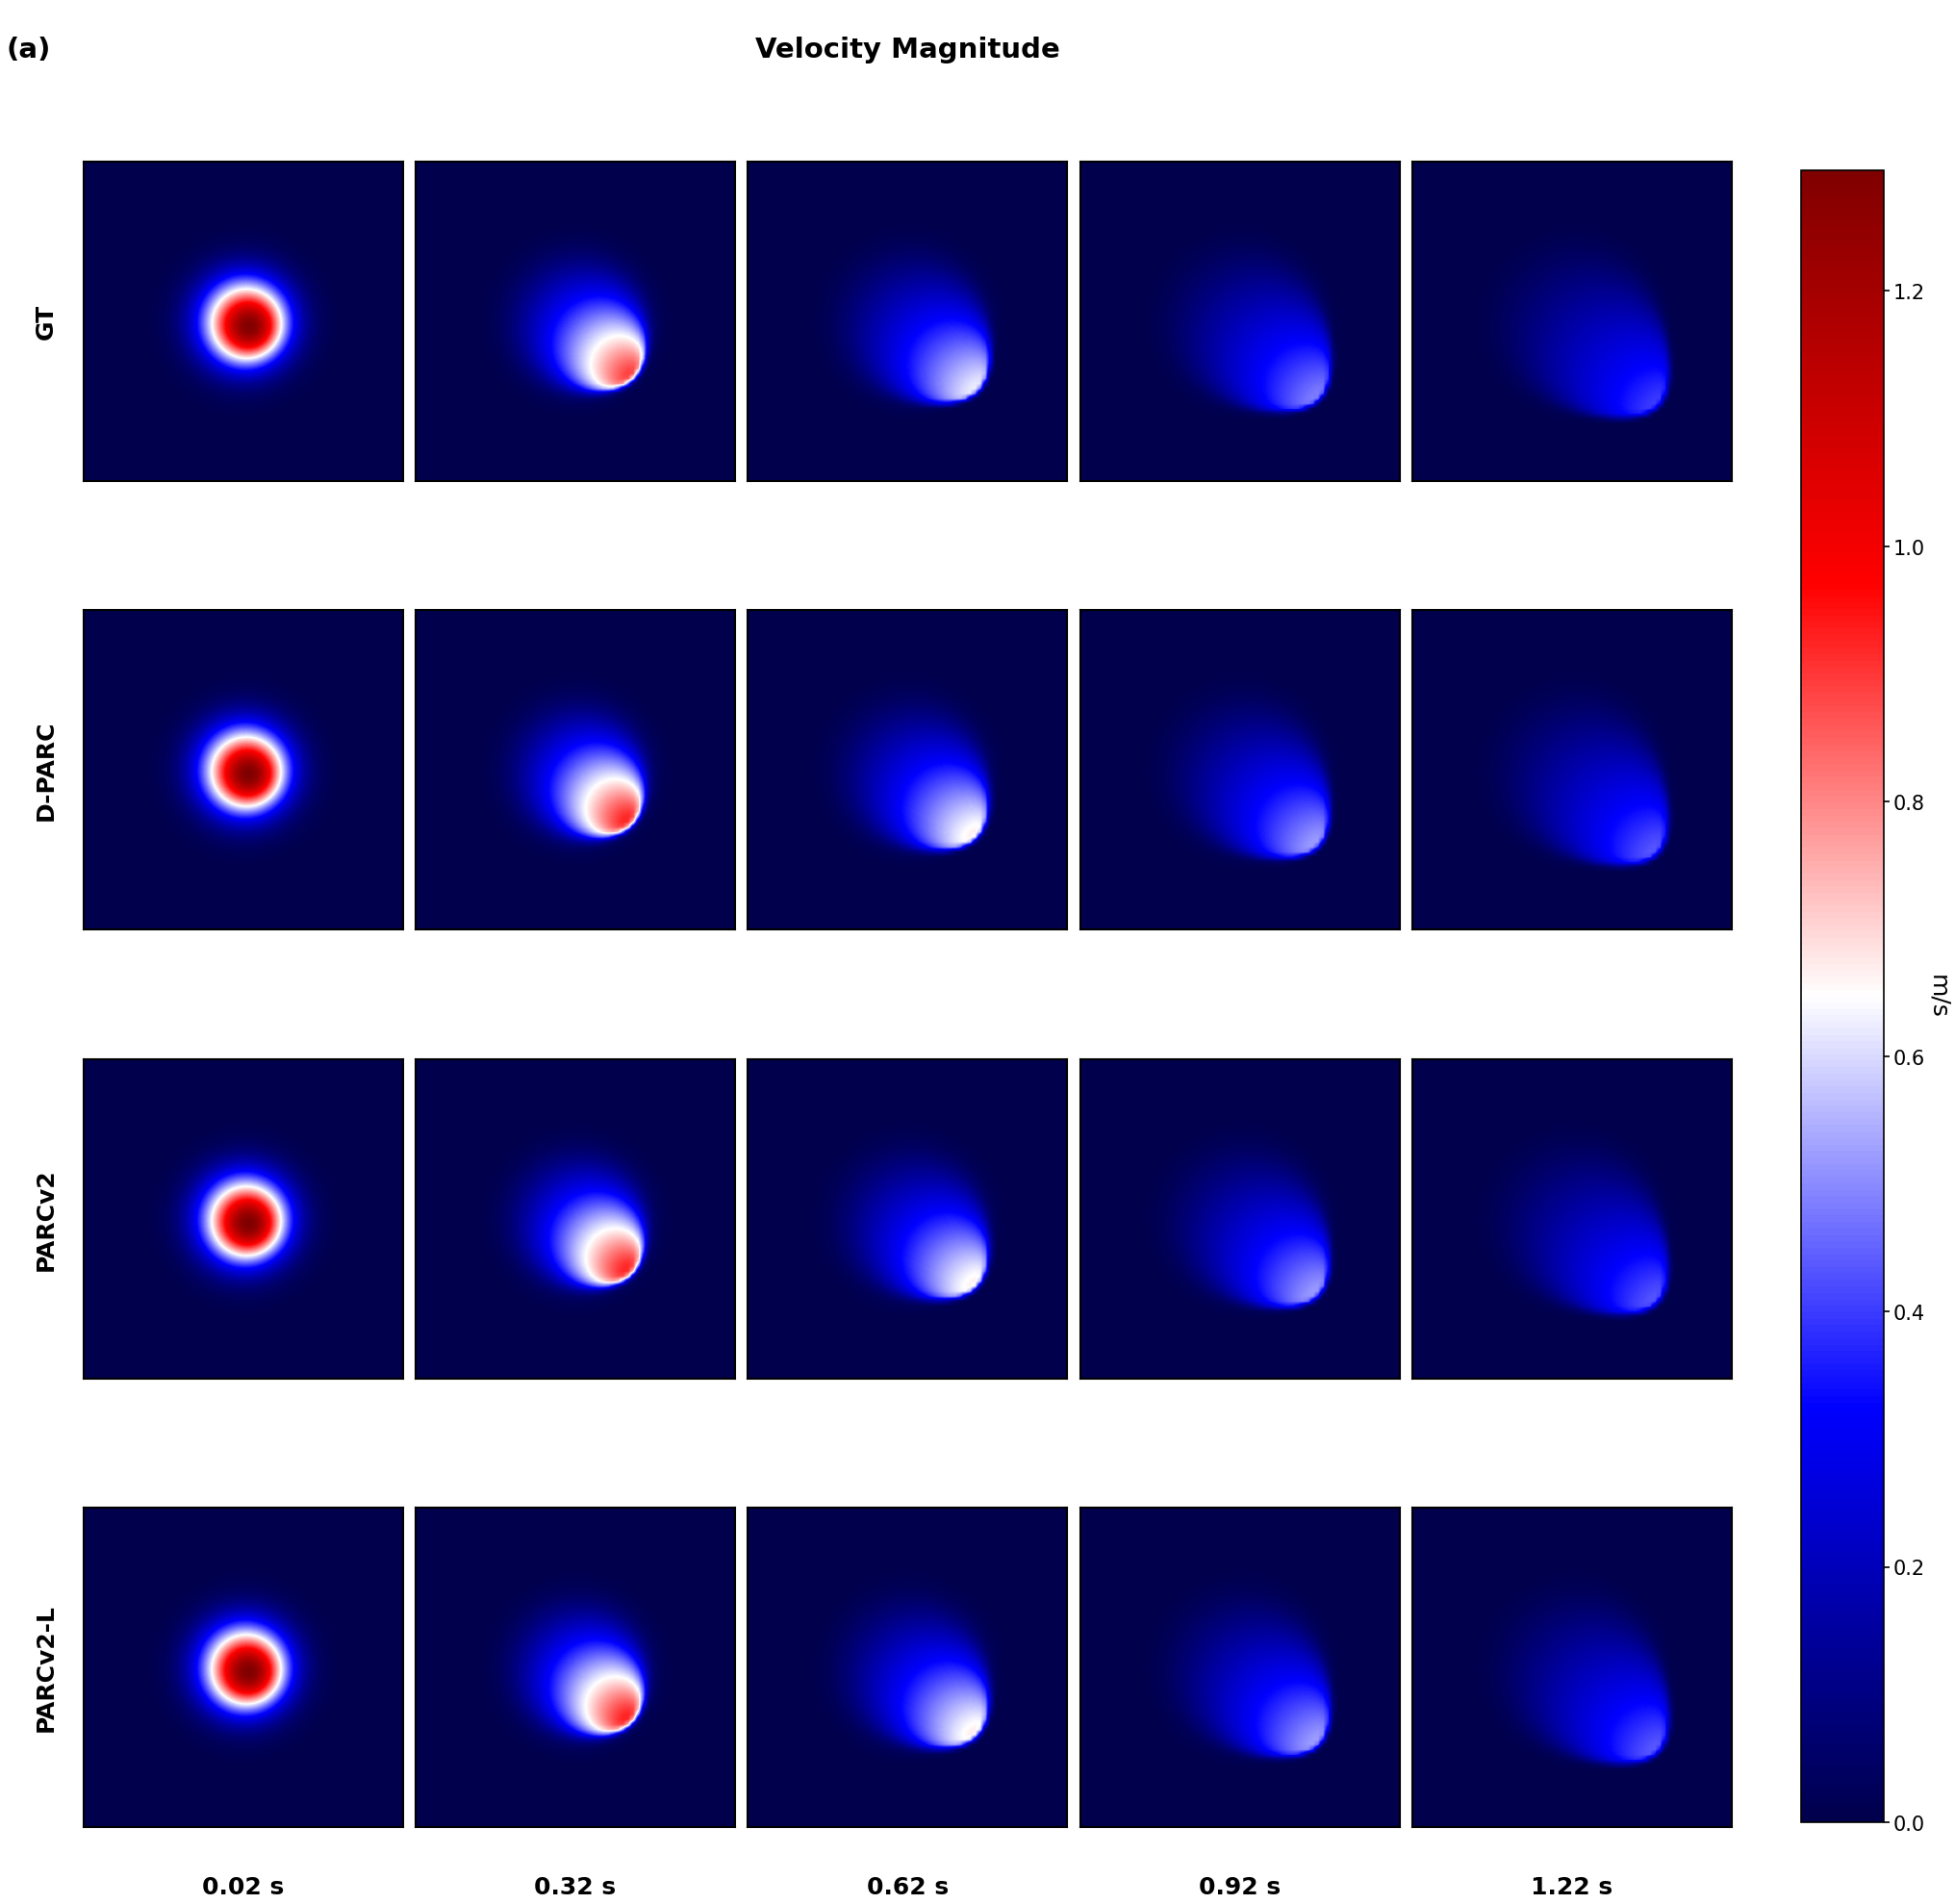

✓ Plot saved as PDF: ../results/comparison_burgers/burgers_comparison_models_sample121.pdf
✓ Plot saved as PNG: ../results/comparison_burgers/burgs_comparison_models_sample121.png

✓ Visualization complete!


In [17]:
################################################################################
# CELL 7 (Combined): Data Prep, Styling, and Visualization
################################################################################

# --- Imports for this cell ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from pathlib import Path
import os
import torch  # Assuming torch was imported in an earlier cell

# --- Set the sample you want from the *entire* dataset (0-377) ---
SAMPLE_ID_TO_COMPARE = 121 

# --- 7a. Load Data for Visualization (Corrected) ---
print("Loading evaluation dataset...")
eval_dataset = GenericPhysicsDataset(
    data_dirs=[EVAL_DATA_DIR],
    future_steps=FUTURE_STEPS,
    min_max_path=MIN_MAX_PATH
)
# We need the collate_fn to manually build a batch
eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE, # BATCH_SIZE is still needed by the collate_fn
    shuffle=False,
    num_workers=1,
    pin_memory=True if DEVICE == 'cuda' else False,
    collate_fn=custom_collate_fn
)
print(f"✓ Dataset loaded. Total samples: {len(eval_dataset)}")

# --- 7b. Run Predictions for Visualization (Corrected) ---
print(f"Loading SPECIFIC sample {SAMPLE_ID_TO_COMPARE} for visualization...")

if SAMPLE_ID_TO_COMPARE >= len(eval_dataset):
    print(f"⚠️ SAMPLE_ID_TO_COMPARE ({SAMPLE_ID_TO_COMPARE}) is out of dataset range! Defaulting to sample 0.")
    SAMPLE_ID_TO_COMPARE = 0

# --- KEY CHANGE: Get the specific sample AND create a batch of size 1 ---
sample_data = eval_dataset[SAMPLE_ID_TO_COMPARE]
batch = custom_collate_fn([sample_data]) # Use collate_fn to build a batch of size 1

print("Running predictions on the single sample...")
ic, t0, t1, ground_truth = batch

ic = ic.to(DEVICE)
t0 = t0.to(DEVICE)
t1 = t1.to(DEVICE)
ground_truth = ground_truth.to(DEVICE)

with torch.no_grad():
    pred_deform = model_deform(ic, t0, t1)
    pred_standard = model_standard(ic, t0, t1)
    pred_large = model_large(ic, t0, t1)

print(f"✓ Predictions complete")

# --- 7c. Check Alignment ---
print("\n" + "="*80)
print("CHECKING DATA ALIGNMENT")
print(f"IC shape: {ic.shape}, Ground truth shape: {ground_truth.shape}")
ic_matches_gt0 = torch.allclose(ic[0], ground_truth[0, 0], atol=1e-6)
print(f"Does IC match GT[0]? {ic_matches_gt0}")
if ic_matches_gt0:
    print("✓ Ground truth INCLUDES t=0. Alignment: pred[t] ↔ gt[t+1]")
else:
    print("✓ Ground truth EXCLUDES t=0. Alignment: pred[t] ↔ gt[t]")
print("="*80 + "\n")


# --- 7e (Refactored): Plotting Style Function (Using 'Arial' from learned script) ---
def set_publication_style():
    """Set publication-quality matplotlib style parameters."""
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'font.size': 6,
        'axes.labelsize': 6,
        'axes.titlesize': 7,
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'legend.fontsize': 5,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,
        'axes.linewidth': 0.5,
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
    })

# --- 7d (Refactored): Organize Data for Plotting (Corrected) ---
print("Organizing data for plotting...")
data_to_plot = {}
features_to_plot = [] # Will be auto-populated
models_to_plot = ['ground_truth', 'deform', 'standard', 'large']

# --- KEY CHANGE ---
# The batch (ground_truth, pred_deform) now has ONLY ONE sample.
# We MUST use index 0 to select it.
sample_idx_in_batch = 0 

# --- Check for and process Velocity Magnitude ---
has_vel_u = 'Velocity U' in VIZ_CHANNEL_MAP
has_vel_v = 'Velocity V' in VIZ_CHANNEL_MAP

if has_vel_u and has_vel_v:
    feature_name = 'Velocity Magnitude'
    features_to_plot.append(feature_name)
    data_to_plot[feature_name] = {ts: {} for ts in TIMESTEPS_TO_COMPARE}
    
    u_idx = VIZ_CHANNEL_MAP['Velocity U']
    v_idx = VIZ_CHANNEL_MAP['Velocity V']
    
    print(f"Processing {feature_name}...")
    for ts in TIMESTEPS_TO_COMPARE:
        if ts >= ground_truth.shape[0]:
            print(f"⚠️ Timestep {ts} out of range, skipping...")
            continue
            
        for model_name, pred_tensor in zip(models_to_plot, [ground_truth, pred_deform, pred_standard, pred_large]):
            
            if model_name == 'ground_truth':
                # Special handling for GT shape (if different)
                u_data = pred_tensor[ts, sample_idx_in_batch, u_idx, :, :].cpu()
                v_data = pred_tensor[ts, sample_idx_in_batch, v_idx, :, :].cpu()
            else:
                u_data = pred_tensor[ts, sample_idx_in_batch, u_idx, :, :].cpu()
                v_data = pred_tensor[ts, sample_idx_in_batch, v_idx, :, :].cpu()

            # Denormalize
            u_denorm = denormalize(u_idx, u_data, norm_params).numpy()
            v_denorm = denormalize(v_idx, v_data, norm_params).numpy()
            
            # Calculate and store magnitude
            magnitude = np.sqrt(u_denorm**2 + v_denorm**2)
            data_to_plot[feature_name][ts][model_name] = magnitude

# --- Process all other features ---
for feature_name, channel_idx in VIZ_CHANNEL_MAP.items():
    if feature_name in ['Velocity U', 'Velocity V']:
        continue  # Already processed into magnitude

    print(f"Processing {feature_name}...")
    features_to_plot.append(feature_name)
    data_to_plot[feature_name] = {ts: {} for ts in TIMESTEPS_TO_COMPARE}
    
    for ts in TIMESTEPS_TO_COMPARE:
        if ts >= ground_truth.shape[0]:
            print(f"⚠️ Timestep {ts} out of range, skipping...")
            continue
            
        for model_name, pred_tensor in zip(models_to_plot, [ground_truth, pred_deform, pred_standard, pred_large]):
            
            if model_name == 'ground_truth':
                data = pred_tensor[ts, sample_idx_in_batch, channel_idx, :, :].cpu()
            else:
                data = pred_tensor[ts, sample_idx_in_batch, channel_idx, :, :].cpu()
                
            # Denormalize
            denorm_data = denormalize(channel_idx, data, norm_params).numpy()
            data_to_plot[feature_name][ts][model_name] = denorm_data

# This print statement now correctly refers to the global sample ID
print(f"✓ Data organized for plotting Sample {SAMPLE_ID_TO_COMPARE}")

# --- IMPORTANT: Update CMAP_CONFIG for Velocity Magnitude ---
if 'Velocity Magnitude' not in CMAP_CONFIG:
    CMAP_CONFIG['Velocity Magnitude'] = {'cmap': 'seismic', 'label': 'm/s'}
    print("Added default CMAP_CONFIG for 'Velocity Magnitude'")
if 'Velocity U' in CMAP_CONFIG:
    del CMAP_CONFIG['Velocity U']
if 'Velocity V' in CMAP_CONFIG:
    del CMAP_CONFIG['Velocity V']


# --- 7f (Refactored): Generate Plot ---
print("\nGenerating plot...")
if not data_to_plot:
    print("⚠️ The `data_to_plot` dictionary is empty.")
else:
    set_publication_style()
    
    features = features_to_plot 
    timesteps = TIMESTEPS_TO_COMPARE
    num_features = len(features)
    num_timesteps = len(timesteps)
    
    row_names = ['ground_truth', 'deform', 'standard', 'large']
    row_labels = ['GT', 'D-PARC', 'PARCv2', 'PARCv2-L']
    num_models = len(row_names)
    
    # --- Figure Sizing ---
    first_grid = next(iter(next(iter(data_to_plot.values())).values()))['ground_truth']
    ny, nx = first_grid.shape
    data_aspect_ratio = ny / nx

    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    
    panel_height_in = (fig_width_in / num_timesteps) * data_aspect_ratio
    fig_height_in = panel_height_in * (num_models + 0.5) * num_features * 1.1 # 1.1 for hspace
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    
    # --- Outer GridSpec ---
    outer_gs = gridspec.GridSpec(
        num_features, 2, figure=fig,
        width_ratios=[1, 0.05], # Plot column, Cbar column
        wspace=0.08, hspace=0.2, # hspace between feature blocks
        top=0.98, bottom=0.05, left=0.1, right=0.98
    )
    
    subfig_labels = ['a', 'b', 'c', 'd', 'e', 'f']
    
    for i, feature in enumerate(features):
        
        # --- Determine vmin/vmax for the *entire feature block* ---
        all_grids = []
        for ts in timesteps:
            if ts not in data_to_plot[feature]: continue
            for model_name in row_names:
                if model_name in data_to_plot[feature][ts]:
                    all_grids.append(data_to_plot[feature][ts][model_name])
        
        if not all_grids:
            print(f"⚠️ No data found for feature {feature}, skipping block.")
            continue
            
        vmin = min(g.min() for g in all_grids)
        vmax = max(g.max() for g in all_grids)
        
        cmap = CMAP_CONFIG[feature]['cmap']
        cbar_label = CMAP_CONFIG[feature]['label']
        
        # --- Inner GridSpec (for title + model rows) ---
        inner_gs_spec = outer_gs[i, 0]
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            num_models + 1, num_timesteps, subplot_spec=inner_gs_spec,
            height_ratios=[0.2] + [1] * num_models, # Title row + Model rows
            hspace=0.02, wspace=0.04
        )
        
        # --- Feature Title ---
        title_ax = fig.add_subplot(inner_gs[0, :])
        
        # (a) Subfigure label
        title_ax.text(-0.02, 0.5, f"({subfig_labels[i]})",
                      fontsize=7, weight='bold',
                      rotation=0, va='center', ha='right',
                      transform=title_ax.transAxes)
        
        # Feature name
        feature_display = feature.replace('_', ' ').title()
        title_ax.text(0.5, 0.5, feature_display,
                      fontsize=7, weight='bold',
                      va='center', ha='center',
                      transform=title_ax.transAxes)
        title_ax.axis('off')

        # --- Plotting Loop (Models x Timesteps) ---
        im = None 
        for row_idx, (row_name, row_label) in enumerate(zip(row_names, row_labels)):
            for j, ts in enumerate(timesteps):
                ax = fig.add_subplot(inner_gs[row_idx + 1, j])
                
                if ts in data_to_plot[feature] and row_name in data_to_plot[feature][ts]:
                    grid = data_to_plot[feature][ts][row_name]
                    im = ax.imshow(
                        grid, cmap=cmap, vmin=vmin, vmax=vmax,
                        interpolation='bilinear', aspect='equal', origin='upper'
                    )
                else:
                    ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                            transform=ax.transAxes, fontsize=5)

                # --- Labels ---
                if row_idx == num_models - 1: # Time labels (bottom row only)
                    time_seconds = (ts + 1) * TIME_PER_STEP 
                    ax.text(0.5, -0.15, f"{time_seconds:.2f} s", fontsize=6,
                            ha='center', va='top', transform=ax.transAxes,
                            weight='bold')
                
                if j == 0: # Row (Model) labels (first column only)
                    ax.text(-0.08, 0.5, row_label, fontsize=6, weight='bold',
                            rotation=90, va='center', ha='right',
                            transform=ax.transAxes)
                
                ax.set_xticks([])
                ax.set_yticks([])

        # --- Colorbar (Shorter) ---
        if im:
            cbar_gs = gridspec.GridSpecFromSubplotSpec(
                3, 1, subplot_spec=outer_gs[i, 1],
                height_ratios=[0.1, 1, 0.04], # Top empty, cbar, bottom empty
                hspace=0 
            )
            cax = fig.add_subplot(cbar_gs[1, 0]) # Place colorbar in middle slot

            cbar = plt.colorbar(im, cax=cax, aspect=15) 
            cbar.ax.tick_params(labelsize=5, width=0.4, length=1.5, pad=1)
            cbar.outline.set_linewidth(0.4)
            if cbar_label:
                cbar.set_label(cbar_label, rotation=270, labelpad=6, fontsize=6)

    # --- Save the figure ---
    output_dir = Path(OUTPUT_DIR)
    output_dir.mkdir(exist_ok=True)
    
    # Filename now correctly uses the global sample ID
    pdf_path = output_dir / f"burgers_comparison_models_sample{SAMPLE_ID_TO_COMPARE}.pdf"
    png_path = output_dir / f"burgs_comparison_models_sample{SAMPLE_ID_TO_COMPARE}.png"

    plt.savefig(pdf_path)
    plt.savefig(png_path)
    plt.show()
    plt.close(fig)

    print(f"✓ Plot saved as PDF: {pdf_path}")
    print(f"✓ Plot saved as PNG: {png_path}")

print("\n" + "="*80)
print("✓ Visualization complete!")
print("="*80)

In [18]:
################################################################################
# CELL 8: Find All Test Files (for Metrics)
################################################################################

test_files = sorted(glob.glob(os.path.join(EVAL_DATA_DIR, '*.npy')))
print(f"Found {len(test_files)} simulation files for metrics calculation.")

Found 378 simulation files for metrics calculation.


In [19]:
################################################################################
# CELL 9E: Task 3E - Wall Clock Time Benchmark (Inference, Resolution-Normalized)
################################################################################

import time
import platform

# Set this once per notebook: "burgers", "navier_stokes", or "em"
DATASET_TAG = "burgers"  # <-- change this per notebook

print("\n" + "="*80)
print(f"[{DATASET_TAG}] BENCHMARKING WALL CLOCK INFERENCE TIME")
print("="*80)

# ============================================================================
# HARDWARE INFO (for reproducibility / reporting alongside timing results)
# ============================================================================
print("\n" + "="*80)
print("HARDWARE CONFIGURATION")
print("="*80)

if torch.cuda.is_available():
    gpu_idx = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(gpu_idx)
    gpu_props = torch.cuda.get_device_properties(gpu_idx)
    total_mem_gb = gpu_props.total_memory / (1024**3)
    cuda_version = torch.version.cuda
    cudnn_version = torch.backends.cudnn.version()

    print(f"GPU: {gpu_name}")
    print(f"Total GPU Memory: {total_mem_gb:.2f} GB")
    print(f"Compute Capability: {gpu_props.major}.{gpu_props.minor}")
    print(f"CUDA Version: {cuda_version}")
    print(f"cuDNN Version: {cudnn_version}")
    print(f"PyTorch Version: {torch.__version__}")

    hardware_info = {
        'device': gpu_name,
        'total_memory_gb': f'{total_mem_gb:.2f}',
        'compute_capability': f'{gpu_props.major}.{gpu_props.minor}',
        'cuda_version': str(cuda_version),
        'cudnn_version': str(cudnn_version),
        'pytorch_version': torch.__version__,
    }
else:
    cpu_name = platform.processor() or "Unknown CPU"
    print(f"No GPU detected — running on CPU: {cpu_name}")
    print(f"PyTorch Version: {torch.__version__}")

    hardware_info = {
        'device': f'CPU ({cpu_name})',
        'total_memory_gb': 'N/A',
        'compute_capability': 'N/A',
        'cuda_version': 'N/A',
        'cudnn_version': 'N/A',
        'pytorch_version': torch.__version__,
    }
print("="*80)

# ============================================================================
# CONFIG
# ============================================================================
N_WARMUP = 10          # untimed warmup runs — lets cuDNN pick kernels, avoids first-call overhead
N_TRIALS = 50          # timed runs to average over
BENCHMARK_BATCH_SIZE = 1  # set >1 if you want throughput at larger batch sizes too

models_to_benchmark = {
    'D-PARC': model_deform,
    'PARCv2': model_standard,
    'PARCv2-L': model_large,
}

# Use one representative test file to build a realistic input (same shape as your real inference)
sample_file = test_files[0]
full_sim = np.load(sample_file)
full_sim_tensor = torch.from_numpy(full_sim).float().to(DEVICE)

normalized_sim = torch.zeros_like(full_sim_tensor)
for ch in range(full_sim_tensor.shape[1]):
    channel_min = norm_params["channel_min"][ch]
    channel_max = norm_params["channel_max"][ch]
    normalized_sim[:, ch, :, :] = (full_sim_tensor[:, ch, :, :] - channel_min) / (channel_max - channel_min)

ic_single = normalized_sim[0:1, :, :, :]
ic = ic_single.repeat(BENCHMARK_BATCH_SIZE, 1, 1, 1)  # replicate for batch-size testing

# Capture spatial resolution for cross-dataset normalization
grid_h, grid_w = ic_single.shape[-2], ic_single.shape[-1]
n_pixels = grid_h * grid_w
n_megapixels = n_pixels / 1e6
print(f"\nGrid resolution: {grid_h} x {grid_w}  ({n_megapixels:.4f} megapixels)")

num_steps_to_predict = min(FUTURE_STEPS, full_sim_tensor.shape[0] - 1)
t0 = torch.tensor(0.0, device=DEVICE)
t1 = torch.arange(1, num_steps_to_predict + 1, dtype=torch.float32, device=DEVICE) / num_steps_to_predict

# ============================================================================
# BENCHMARK FUNCTION
# ============================================================================
def benchmark_model(model, ic, t0, t1, n_warmup, n_trials, device):
    model.eval()
    use_cuda = (device.type == 'cuda') if isinstance(device, torch.device) else ('cuda' in str(device))

    # --- Warmup (untimed) ---
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(ic, t0, t1)
    if use_cuda:
        torch.cuda.synchronize()

    times_ms = []

    if use_cuda:
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)
        with torch.no_grad():
            for _ in range(n_trials):
                starter.record()
                _ = model(ic, t0, t1)
                ender.record()
                torch.cuda.synchronize()
                times_ms.append(starter.elapsed_time(ender))  # milliseconds
    else:
        # CPU fallback: perf_counter is safe here since CPU ops are synchronous
        with torch.no_grad():
            for _ in range(n_trials):
                start = time.perf_counter()
                _ = model(ic, t0, t1)
                end = time.perf_counter()
                times_ms.append((end - start) * 1000.0)

    times_ms = np.array(times_ms)
    return times_ms

# ============================================================================
# RUN BENCHMARKS
# ============================================================================
timing_results = {}

for model_name, model in models_to_benchmark.items():
    print(f"\nBenchmarking {model_name}...")
    times_ms = benchmark_model(model, ic, t0, t1, N_WARMUP, N_TRIALS, DEVICE)
    timing_results[model_name] = times_ms

    mean_ms = times_ms.mean()
    std_ms = times_ms.std()
    median_ms = np.median(times_ms)
    per_step_ms = mean_ms / num_steps_to_predict

    print(f"  Full rollout ({num_steps_to_predict} steps): "
          f"{mean_ms:.3f} ± {std_ms:.3f} ms  (median: {median_ms:.3f} ms)")
    print(f"  Per-timestep: {per_step_ms:.4f} ms/step")

# ============================================================================
# PRINT COMPARISON TABLE + RELATIVE SPEEDUP (RESOLUTION-NORMALIZED)
# ============================================================================
print("\n" + "="*80)
print(f"[{DATASET_TAG}] WALL CLOCK TIME COMPARISON (Full Rollout)")
print("="*80)
print(f"{'Model':<15} {'Mean (ms)':<15} {'Per-Step (ms)':<18} {'Per-Step/MPx (ms)':<20} {'Relative to PARCv2':<20}")
print("-" * 100)

baseline_mean = timing_results['PARCv2'].mean()

timing_csv_rows = []
for model_name, times_ms in timing_results.items():
    mean_ms = times_ms.mean()
    std_ms = times_ms.std()
    per_step_ms = mean_ms / num_steps_to_predict
    per_step_per_mpx_ms = per_step_ms / n_megapixels  # resolution-normalized
    relative = mean_ms / baseline_mean

    relative_str = f"{relative:.2f}x" if model_name != 'PARCv2' else "1.00x (baseline)"
    print(f"{model_name:<15} {mean_ms:<15.3f} {per_step_ms:<18.4f} {per_step_per_mpx_ms:<20.4f} {relative_str:<20}")

    timing_csv_rows.append([
        model_name, f'{mean_ms:.4f}', f'{std_ms:.4f}', f'{np.median(times_ms):.4f}',
        f'{per_step_ms:.5f}', f'{per_step_per_mpx_ms:.5f}', f'{relative:.4f}',
        f'{grid_h}x{grid_w}',
    ])

# ============================================================================
# SAVE TO CSV (with hardware metadata header)
# ============================================================================
timing_csv_path = os.path.join(OUTPUT_DIR, f'wall_clock_timing_{DATASET_TAG}.csv')
with open(timing_csv_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['# Hardware Configuration'])
    for key, val in hardware_info.items():
        writer.writerow([f'# {key}', val])
    writer.writerow([])  # blank line separating metadata from data
    writer.writerow(['Model', 'Mean_ms', 'Std_ms', 'Median_ms', 'Per_Step_ms',
                      'Per_Step_Per_Megapixel_ms', 'Relative_to_PARCv2', 'Grid_Resolution'])
    writer.writerows(timing_csv_rows)

print(f"\n✓ [{DATASET_TAG}] Wall clock timing results saved to: {timing_csv_path}")
print("="*80)


[burgers] BENCHMARKING WALL CLOCK INFERENCE TIME

HARDWARE CONFIGURATION
GPU: NVIDIA RTX A6000
Total GPU Memory: 47.40 GB
Compute Capability: 8.6
CUDA Version: 12.8
cuDNN Version: 91002
PyTorch Version: 2.9.1+cu128

Grid resolution: 64 x 64  (0.0041 megapixels)

Benchmarking D-PARC...
  Full rollout (100 steps): 1344.778 ± 68.285 ms  (median: 1334.755 ms)
  Per-timestep: 13.4478 ms/step

Benchmarking PARCv2...
  Full rollout (100 steps): 1123.416 ± 128.549 ms  (median: 1091.805 ms)
  Per-timestep: 11.2342 ms/step

Benchmarking PARCv2-L...
  Full rollout (100 steps): 2280.469 ± 1380.216 ms  (median: 1461.985 ms)
  Per-timestep: 22.8047 ms/step

[burgers] WALL CLOCK TIME COMPARISON (Full Rollout)
Model           Mean (ms)       Per-Step (ms)      Per-Step/MPx (ms)    Relative to PARCv2  
----------------------------------------------------------------------------------------------------
D-PARC          1344.778        13.4478            3283.1506            1.20x               
PARCv2  

In [9]:
################################################################################
# CELL 9: Task 3 - Calculate Global RMSE + SSIM
################################################################################

from skimage.metrics import structural_similarity as ssim_sk  # NEW

print("\n" + "="*80)
print("COMPUTING PER-CHANNEL GLOBAL RMSE + SSIM (ALL 3 MODELS)")
print("="*80)

# Initialize accumulators for all three models
squared_error_sum_deform_norm = {}
squared_error_sum_standard_norm = {}
squared_error_sum_large_norm = {}
squared_error_sum_deform_denorm = {}
squared_error_sum_standard_denorm = {}
squared_error_sum_large_denorm = {}
element_count = {}

# NEW: SSIM accumulators
ssim_sum_deform = {}
ssim_sum_standard = {}
ssim_sum_large = {}
ssim_frame_count = {}

for feature_name in METRICS_CHANNEL_MAP.keys():
    squared_error_sum_deform_norm[feature_name] = 0.0
    squared_error_sum_standard_norm[feature_name] = 0.0
    squared_error_sum_large_norm[feature_name] = 0.0
    squared_error_sum_deform_denorm[feature_name] = 0.0
    squared_error_sum_standard_denorm[feature_name] = 0.0
    squared_error_sum_large_denorm[feature_name] = 0.0
    element_count[feature_name] = 0
    # NEW
    ssim_sum_deform[feature_name] = 0.0
    ssim_sum_standard[feature_name] = 0.0
    ssim_sum_large[feature_name] = 0.0
    ssim_frame_count[feature_name] = 0

# NEW: helper for SSIM on a [T, H, W] field pair
def compute_ssim_series(pred_field, gt_field):
    pred_np = pred_field.detach().cpu().numpy()
    gt_np = gt_field.detach().cpu().numpy()
    data_range = gt_np.max() - gt_np.min()
    if data_range == 0:
        data_range = 1e-8
    frame_ssims = [
        ssim_sk(gt_np[t], pred_np[t], data_range=data_range)
        for t in range(pred_np.shape[0])
    ]
    return float(np.mean(frame_ssims))

for file_idx, test_file in enumerate(test_files):
    progress = (file_idx + 1) / len(test_files)
    bar_length = 40
    filled_length = int(bar_length * progress)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    print(f'\rProcessing: |{bar}| {file_idx + 1}/{len(test_files)} ({progress:.1%})', end='', flush=True)
    
    full_sim = np.load(test_file)
    full_sim_tensor = torch.from_numpy(full_sim).float().to(DEVICE)
    
    normalized_sim = torch.zeros_like(full_sim_tensor)
    for ch in range(full_sim_tensor.shape[1]):
        channel_min = norm_params["channel_min"][ch]
        channel_max = norm_params["channel_max"][ch]
        normalized_sim[:, ch, :, :] = (full_sim_tensor[:, ch, :, :] - channel_min) / (channel_max - channel_min)
    
    ic = normalized_sim[0:1, :, :, :]
    num_steps_to_predict = min(FUTURE_STEPS, full_sim_tensor.shape[0] - 1)
    t0 = torch.tensor(0.0, device=DEVICE)
    t1 = torch.arange(1, num_steps_to_predict + 1, dtype=torch.float32, device=DEVICE) / num_steps_to_predict
    ground_truth_file = normalized_sim[1:num_steps_to_predict+1, :, :, :].unsqueeze(1)
    
    with torch.no_grad():
        pred_deform_file = model_deform(ic, t0, t1)
        pred_standard_file = model_standard(ic, t0, t1)
        pred_large_file = model_large(ic, t0, t1)
    
    min_len = min(pred_deform_file.shape[0], ground_truth_file.shape[0])
    pred_deform_aligned = pred_deform_file[:min_len]
    pred_standard_aligned = pred_standard_file[:min_len]
    pred_large_aligned = pred_large_file[:min_len]
    gt_aligned = ground_truth_file[:min_len]
    
    for feature_name, channel_idx in METRICS_CHANNEL_MAP.items():
        if isinstance(channel_idx, tuple):
            ch_u, ch_v = channel_idx
            
            gt_u_norm = gt_aligned[:, 0, ch_u, :, :]
            gt_v_norm = gt_aligned[:, 0, ch_v, :, :]
            pred_d_u_norm = pred_deform_aligned[:, 0, ch_u, :, :]
            pred_d_v_norm = pred_deform_aligned[:, 0, ch_v, :, :]
            pred_s_u_norm = pred_standard_aligned[:, 0, ch_u, :, :]
            pred_s_v_norm = pred_standard_aligned[:, 0, ch_v, :, :]
            pred_l_u_norm = pred_large_aligned[:, 0, ch_u, :, :]
            pred_l_v_norm = pred_large_aligned[:, 0, ch_v, :, :]
            
            gt_vel_mag_norm = torch.sqrt(gt_u_norm**2 + gt_v_norm**2)
            pred_d_vel_mag_norm = torch.sqrt(pred_d_u_norm**2 + pred_d_v_norm**2)
            pred_s_vel_mag_norm = torch.sqrt(pred_s_u_norm**2 + pred_s_v_norm**2)
            pred_l_vel_mag_norm = torch.sqrt(pred_l_u_norm**2 + pred_l_v_norm**2)
            
            sq_err_d_norm = (pred_d_vel_mag_norm - gt_vel_mag_norm) ** 2
            sq_err_s_norm = (pred_s_vel_mag_norm - gt_vel_mag_norm) ** 2
            sq_err_l_norm = (pred_l_vel_mag_norm - gt_vel_mag_norm) ** 2
            
            squared_error_sum_deform_norm[feature_name] += torch.sum(sq_err_d_norm).item()
            squared_error_sum_standard_norm[feature_name] += torch.sum(sq_err_s_norm).item()
            squared_error_sum_large_norm[feature_name] += torch.sum(sq_err_l_norm).item()
            
            gt_u_denorm = denormalize(ch_u, gt_u_norm, norm_params)
            gt_v_denorm = denormalize(ch_v, gt_v_norm, norm_params)
            pred_d_u_denorm = denormalize(ch_u, pred_d_u_norm, norm_params)
            pred_d_v_denorm = denormalize(ch_v, pred_d_v_norm, norm_params)
            pred_s_u_denorm = denormalize(ch_u, pred_s_u_norm, norm_params)
            pred_s_v_denorm = denormalize(ch_v, pred_s_v_norm, norm_params)
            pred_l_u_denorm = denormalize(ch_u, pred_l_u_norm, norm_params)
            pred_l_v_denorm = denormalize(ch_v, pred_l_v_norm, norm_params)
            
            gt_vel_mag_denorm = torch.sqrt(gt_u_denorm**2 + gt_v_denorm**2)
            pred_d_vel_mag_denorm = torch.sqrt(pred_d_u_denorm**2 + pred_d_v_denorm**2)
            pred_s_vel_mag_denorm = torch.sqrt(pred_s_u_denorm**2 + pred_s_v_denorm**2)
            pred_l_vel_mag_denorm = torch.sqrt(pred_l_u_denorm**2 + pred_l_v_denorm**2)
            
            sq_err_d_denorm = (pred_d_vel_mag_denorm - gt_vel_mag_denorm) ** 2
            sq_err_s_denorm = (pred_s_vel_mag_denorm - gt_vel_mag_denorm) ** 2
            sq_err_l_denorm = (pred_l_vel_mag_denorm - gt_vel_mag_denorm) ** 2
            
            squared_error_sum_deform_denorm[feature_name] += torch.sum(sq_err_d_denorm).item()
            squared_error_sum_standard_denorm[feature_name] += torch.sum(sq_err_s_denorm).item()
            squared_error_sum_large_denorm[feature_name] += torch.sum(sq_err_l_denorm).item()
            
            element_count[feature_name] += gt_vel_mag_norm.numel()

            # NEW: SSIM on the denormalized (physical-units) velocity magnitude field
            ssim_sum_deform[feature_name] += compute_ssim_series(pred_d_vel_mag_denorm, gt_vel_mag_denorm)
            ssim_sum_standard[feature_name] += compute_ssim_series(pred_s_vel_mag_denorm, gt_vel_mag_denorm)
            ssim_sum_large[feature_name] += compute_ssim_series(pred_l_vel_mag_denorm, gt_vel_mag_denorm)
            ssim_frame_count[feature_name] += 1

print("\n") # New line after progress bar

# --- Calculate and Print RMSE Results ---
print("\n" + "="*80)
print("PER-CHANNEL GLOBAL RMSE RESULTS (NORMALIZED)")
print("="*80)
print(f"{'Channel':<25} {'D-PARC RMSE':<15} {'PARC-v2 RMSE':<15} {'Large RMSE':<15} {'Best Model':<15}")
print("-" * 85)

channel_rmse_deform_norm = {}
channel_rmse_standard_norm = {}
channel_rmse_large_norm = {}
channel_rmse_deform_denorm = {}
channel_rmse_standard_denorm = {}
channel_rmse_large_denorm = {}
results_for_csv = []

for feature_name in METRICS_CHANNEL_MAP.keys():
    rmse_d_norm = np.sqrt(squared_error_sum_deform_norm[feature_name] / element_count[feature_name])
    rmse_s_norm = np.sqrt(squared_error_sum_standard_norm[feature_name] / element_count[feature_name])
    rmse_l_norm = np.sqrt(squared_error_sum_large_norm[feature_name] / element_count[feature_name])
    
    channel_rmse_deform_norm[feature_name] = rmse_d_norm
    channel_rmse_standard_norm[feature_name] = rmse_s_norm
    channel_rmse_large_norm[feature_name] = rmse_l_norm
    
    best_model_norm = "Large"
    if rmse_d_norm <= min(rmse_s_norm, rmse_l_norm): best_model_norm = "D-PARC"
    elif rmse_s_norm <= min(rmse_d_norm, rmse_l_norm): best_model_norm = "PARC-v2"
    
    print(f"{feature_name:<25} {rmse_d_norm:<15.10f} {rmse_s_norm:<15.10f} {rmse_l_norm:<15.10f} {best_model_norm:<15}")

print("\n" + "="*80)
print("PER-CHANNEL GLOBAL RMSE RESULTS (DENORMALIZED - PHYSICAL UNITS)")
print("="*80)
print(f"{'Channel':<25} {'D-PARC RMSE':<20} {'PARC-v2 RMSE':<20} {'Large RMSE':<20} {'Best':<15}")
print("-" * 100)

for feature_name in METRICS_CHANNEL_MAP.keys():
    rmse_d_denorm = np.sqrt(squared_error_sum_deform_denorm[feature_name] / element_count[feature_name])
    rmse_s_denorm = np.sqrt(squared_error_sum_standard_denorm[feature_name] / element_count[feature_name])
    rmse_l_denorm = np.sqrt(squared_error_sum_large_denorm[feature_name] / element_count[feature_name])
    
    channel_rmse_deform_denorm[feature_name] = rmse_d_denorm
    channel_rmse_standard_denorm[feature_name] = rmse_s_denorm
    channel_rmse_large_denorm[feature_name] = rmse_l_denorm

    best_model_denorm = "Large"
    if rmse_d_denorm <= min(rmse_s_denorm, rmse_l_denorm): best_model_denorm = "D-PARC"
    elif rmse_s_denorm <= min(rmse_d_denorm, rmse_l_denorm): best_model_denorm = "PARC-v2"
    
    units = METRICS_UNITS[feature_name]
    print(f"{feature_name:<25} {rmse_d_denorm:<20.6e} {rmse_s_denorm:<20.6e} {rmse_l_denorm:<20.6e} {best_model_denorm:<15}")
    print(f"{'  (' + units + ')':<25}")

# NEW: --- Calculate and Print SSIM Results ---
print("\n" + "="*80)
print("PER-CHANNEL MEAN SSIM (PHYSICAL FIELDS)")
print("="*80)
print(f"{'Channel':<25} {'D-PARC SSIM':<15} {'PARC-v2 SSIM':<15} {'Large SSIM':<15} {'Best Model':<15}")
print("-" * 85)

channel_ssim_deform = {}
channel_ssim_standard = {}
channel_ssim_large = {}

for feature_name in METRICS_CHANNEL_MAP.keys():
    n = ssim_frame_count[feature_name]
    if n == 0:
        continue  # scalar channels not covered by this branch, skip
    mean_ssim_d = ssim_sum_deform[feature_name] / n
    mean_ssim_s = ssim_sum_standard[feature_name] / n
    mean_ssim_l = ssim_sum_large[feature_name] / n

    channel_ssim_deform[feature_name] = mean_ssim_d
    channel_ssim_standard[feature_name] = mean_ssim_s
    channel_ssim_large[feature_name] = mean_ssim_l

    best_model_ssim = "Large"
    if mean_ssim_d >= max(mean_ssim_s, mean_ssim_l): best_model_ssim = "D-PARC"
    elif mean_ssim_s >= max(mean_ssim_d, mean_ssim_l): best_model_ssim = "PARC-v2"

    print(f"{feature_name:<25} {mean_ssim_d:<15.4f} {mean_ssim_s:<15.4f} {mean_ssim_l:<15.4f} {best_model_ssim:<15}")

# --- Print Relative Improvements ---
print("\n" + "="*80)
print("RELATIVE IMPROVEMENTS (vs PARC-v2 baseline)")
print("="*80)
print(f"\n{'Channel':<25} {'Normalized Space':<30} {'Physical Units':<30}")
print(f"{'':25} {'D-PARC':<15} {'Large':<15} {'D-PARC':<15} {'Large':<15}")
print("-" * 85)

for feature_name in METRICS_CHANNEL_MAP.keys():
    rmse_d_norm = channel_rmse_deform_norm[feature_name]
    rmse_s_norm = channel_rmse_standard_norm[feature_name]
    rmse_l_norm = channel_rmse_large_norm[feature_name]
    improvement_d_norm = ((rmse_s_norm - rmse_d_norm) / rmse_s_norm) * 100
    improvement_l_norm = ((rmse_s_norm - rmse_l_norm) / rmse_s_norm) * 100
    
    rmse_d_denorm = channel_rmse_deform_denorm[feature_name]
    rmse_s_denorm = channel_rmse_standard_denorm[feature_name]
    rmse_l_denorm = channel_rmse_large_denorm[feature_name]
    improvement_d_denorm = ((rmse_s_denorm - rmse_d_denorm) / rmse_s_denorm) * 100
    improvement_l_denorm = ((rmse_s_denorm - rmse_l_denorm) / rmse_s_denorm) * 100
    
    print(f"{feature_name:<25} {improvement_d_norm:+.2f}%{'':<9} {improvement_l_norm:+.2f}%{'':<9} "
          f"{improvement_d_denorm:+.2f}%{'':<9} {improvement_l_denorm:+.2f}%")

    best_model_norm = "Large"
    if rmse_d_norm <= min(rmse_s_norm, rmse_l_norm): best_model_norm = "D-PARC"
    elif rmse_s_norm <= min(rmse_d_norm, rmse_l_norm): best_model_norm = "PARC-v2"
        
    best_model_denorm = "Large"
    if rmse_d_denorm <= min(rmse_s_denorm, rmse_l_denorm): best_model_denorm = "D-PARC"
    elif rmse_s_denorm <= min(rmse_d_denorm, rmse_l_denorm): best_model_denorm = "PARC-v2"

    # NEW: SSIM values for this feature, if computed (else 'N/A' for scalar channels)
    ssim_d_val = f'{channel_ssim_deform[feature_name]:.4f}' if feature_name in channel_ssim_deform else 'N/A'
    ssim_s_val = f'{channel_ssim_standard[feature_name]:.4f}' if feature_name in channel_ssim_standard else 'N/A'
    ssim_l_val = f'{channel_ssim_large[feature_name]:.4f}' if feature_name in channel_ssim_large else 'N/A'

    results_for_csv.append([
        feature_name, METRICS_UNITS[feature_name],
        f'{rmse_d_norm:.10f}', f'{rmse_s_norm:.10f}', f'{rmse_l_norm:.10f}',
        f'{rmse_d_denorm:.6e}', f'{rmse_s_denorm:.6e}', f'{rmse_l_denorm:.6e}',
        best_model_norm, best_model_denorm,
        f'{improvement_d_norm:+.2f}', f'{improvement_l_norm:+.2f}',
        f'{improvement_d_denorm:+.2f}', f'{improvement_l_denorm:+.2f}',
        f'{element_count[feature_name]}',
        ssim_d_val, ssim_s_val, ssim_l_val,  # NEW
    ])

print("\n" + "="*80)

# --- Save RMSE + SSIM Results to CSV ---
csv_path = os.path.join(OUTPUT_DIR, 'per_channel_global_rmse.csv')
with open(csv_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow([
        'Channel', 'Units',
        'D-PARC_RMSE_Normalized', 'PARC-v2_RMSE_Normalized', 'Large_RMSE_Normalized',
        'D-PARC_RMSE_Physical', 'PARC-v2_RMSE_Physical', 'Large_RMSE_Physical',
        'Best_Model_Normalized', 'Best_Model_Physical',
        'D-PARC_Improvement_%_Norm', 'Large_Improvement_%_Norm',
        'D-PARC_Improvement_%_Physical', 'Large_Improvement_%_Physical',
        'Elements_Per_Channel',
        'D-PARC_SSIM', 'PARC-v2_SSIM', 'Large_SSIM',  # NEW
    ])
    writer.writerows(results_for_csv)

print(f"✓ RMSE + SSIM results saved to: {csv_path}")
print("✓ PER-CHANNEL GLOBAL RMSE + SSIM ANALYSIS COMPLETE!")
print("="*80)


COMPUTING PER-CHANNEL GLOBAL RMSE + SSIM (ALL 3 MODELS)
Processing: |████████████████████████████████████████| 378/378 (100.0%)


PER-CHANNEL GLOBAL RMSE RESULTS (NORMALIZED)
Channel                   D-PARC RMSE     PARC-v2 RMSE    Large RMSE      Best Model     
-------------------------------------------------------------------------------------
Velocity Magnitude        0.0189363959    0.0189698491    0.0186329019    Large          

PER-CHANNEL GLOBAL RMSE RESULTS (DENORMALIZED - PHYSICAL UNITS)
Channel                   D-PARC RMSE          PARC-v2 RMSE         Large RMSE           Best           
----------------------------------------------------------------------------------------------------
Velocity Magnitude        1.885478e-02         1.888809e-02         1.855260e-02         Large          
  (m/s)                  

PER-CHANNEL MEAN SSIM (PHYSICAL FIELDS)
Channel                   D-PARC SSIM     PARC-v2 SSIM    Large SSIM      Best Model     
-------------------------

In [20]:
################################################################################
# CELL 9D: Task 3D - Q-Q Plots (All fields in one image) 
#          + Extreme Value Analysis
################################################################################

import os
import csv
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================================
# CONFIG
# ============================================================================
# Caps total retained samples per feature across the whole test set, to keep
# memory and compute tractable. Set to None to keep every value.
MAX_SAMPLES_PER_FEATURE = 200_000

DATASET_TAG = "burgers"  # <-- Dataset tag updated

print("\n" + "="*80)
print(f"[{DATASET_TAG}] COLLECTING FIELD VALUES FOR Q-Q COMPARISON")
print("="*80)

# ============================================================================
# ACCUMULATORS
# ============================================================================
values_gt = {feature_name: [] for feature_name in METRICS_CHANNEL_MAP.keys()}
values_deform = {feature_name: [] for feature_name in METRICS_CHANNEL_MAP.keys()}
values_standard = {feature_name: [] for feature_name in METRICS_CHANNEL_MAP.keys()}
values_large = {feature_name: [] for feature_name in METRICS_CHANNEL_MAP.keys()}

# Per-file extreme-value tracking: GT max location + each model's value AT that location
extreme_records = {feature_name: [] for feature_name in METRICS_CHANNEL_MAP.keys()}

for file_idx, test_file in enumerate(test_files):
    progress = (file_idx + 1) / len(test_files)
    bar_length = 40
    filled_length = int(bar_length * progress)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    print(f'\r[{DATASET_TAG}] Processing: |{bar}| {file_idx + 1}/{len(test_files)} ({progress:.1%})', end='', flush=True)

    full_sim = np.load(test_file)
    full_sim_tensor = torch.from_numpy(full_sim).float().to(DEVICE)

    normalized_sim = torch.zeros_like(full_sim_tensor)
    for ch in range(full_sim_tensor.shape[1]):
        channel_min = norm_params["channel_min"][ch]
        channel_max = norm_params["channel_max"][ch]
        normalized_sim[:, ch, :, :] = (full_sim_tensor[:, ch, :, :] - channel_min) / (channel_max - channel_min)

    ic = normalized_sim[0:1, :, :, :]
    num_steps_to_predict = min(FUTURE_STEPS, full_sim_tensor.shape[0] - 1)
    t0 = torch.tensor(0.0, device=DEVICE)
    t1 = torch.arange(1, num_steps_to_predict + 1, dtype=torch.float32, device=DEVICE) / num_steps_to_predict
    ground_truth_file = normalized_sim[1:num_steps_to_predict+1, :, :, :].unsqueeze(1)

    with torch.no_grad():
        pred_deform_file = model_deform(ic, t0, t1)
        pred_standard_file = model_standard(ic, t0, t1)
        pred_large_file = model_large(ic, t0, t1)

    min_len = min(pred_deform_file.shape[0], ground_truth_file.shape[0])
    pred_deform_aligned = pred_deform_file[:min_len]
    pred_standard_aligned = pred_standard_file[:min_len]
    pred_large_aligned = pred_large_file[:min_len]
    gt_aligned = ground_truth_file[:min_len]

    for feature_name, channel_idx in METRICS_CHANNEL_MAP.items():
        if isinstance(channel_idx, tuple):
            ch_u, ch_v = channel_idx

            gt_u_norm = gt_aligned[:, 0, ch_u, :, :]
            gt_v_norm = gt_aligned[:, 0, ch_v, :, :]
            pred_d_u_norm = pred_deform_aligned[:, 0, ch_u, :, :]
            pred_d_v_norm = pred_deform_aligned[:, 0, ch_v, :, :]
            pred_s_u_norm = pred_standard_aligned[:, 0, ch_u, :, :]
            pred_s_v_norm = pred_standard_aligned[:, 0, ch_v, :, :]
            pred_l_u_norm = pred_large_aligned[:, 0, ch_u, :, :]
            pred_l_v_norm = pred_large_aligned[:, 0, ch_v, :, :]

            gt_u_denorm = denormalize(ch_u, gt_u_norm, norm_params)
            gt_v_denorm = denormalize(ch_v, gt_v_norm, norm_params)
            pred_d_u_denorm = denormalize(ch_u, pred_d_u_norm, norm_params)
            pred_d_v_denorm = denormalize(ch_v, pred_d_v_norm, norm_params)
            pred_s_u_denorm = denormalize(ch_u, pred_s_u_norm, norm_params)
            pred_s_v_denorm = denormalize(ch_v, pred_s_v_norm, norm_params)
            pred_l_u_denorm = denormalize(ch_u, pred_l_u_norm, norm_params)
            pred_l_v_denorm = denormalize(ch_v, pred_l_v_norm, norm_params)

            gt_field = torch.sqrt(gt_u_denorm**2 + gt_v_denorm**2)
            pred_d_field = torch.sqrt(pred_d_u_denorm**2 + pred_d_v_denorm**2)
            pred_s_field = torch.sqrt(pred_s_u_denorm**2 + pred_s_v_denorm**2)
            pred_l_field = torch.sqrt(pred_l_u_denorm**2 + pred_l_v_denorm**2)
        else:
            ch = channel_idx
            gt_ch_norm = gt_aligned[:, 0, ch, :, :]
            pred_d_ch_norm = pred_deform_aligned[:, 0, ch, :, :]
            pred_s_ch_norm = pred_standard_aligned[:, 0, ch, :, :]
            pred_l_ch_norm = pred_large_aligned[:, 0, ch, :, :]

            gt_field = denormalize(ch, gt_ch_norm, norm_params)
            pred_d_field = denormalize(ch, pred_d_ch_norm, norm_params)
            pred_s_field = denormalize(ch, pred_s_ch_norm, norm_params)
            pred_l_field = denormalize(ch, pred_l_ch_norm, norm_params)

        # --- Flatten for distribution accumulation, with per-file subsampling cap ---
        gt_full = gt_field.detach().cpu().numpy()
        d_full = pred_d_field.detach().cpu().numpy()
        s_full = pred_s_field.detach().cpu().numpy()
        l_full = pred_l_field.detach().cpu().numpy()

        gt_np, d_np, s_np, l_np = gt_full.ravel(), d_full.ravel(), s_full.ravel(), l_full.ravel()

        if MAX_SAMPLES_PER_FEATURE is not None:
            per_file_cap = max(1, MAX_SAMPLES_PER_FEATURE // len(test_files))
            if gt_np.size > per_file_cap:
                idx = np.random.choice(gt_np.size, size=per_file_cap, replace=False)
                gt_np, d_np, s_np, l_np = gt_np[idx], d_np[idx], s_np[idx], l_np[idx]

        values_gt[feature_name].append(gt_np)
        values_deform[feature_name].append(d_np)
        values_standard[feature_name].append(s_np)
        values_large[feature_name].append(l_np)

        # --- Extreme-value tracking: use FULL (unsampled) field so the true GT max isn't missed ---
        flat_idx = np.argmax(gt_full)
        extreme_records[feature_name].append({
            'file': os.path.basename(test_file),
            'gt_max': gt_full.flat[flat_idx],
            'd_parc_at_gt_max_loc': d_full.flat[flat_idx],
            'parcv2_at_gt_max_loc': s_full.flat[flat_idx],
            'large_at_gt_max_loc': l_full.flat[flat_idx],
            'd_parc_own_max': d_full.max(),
            'parcv2_own_max': s_full.max(),
            'large_own_max': l_full.max(),
        })

print("\n")

# ============================================================================
# CONCATENATE
# ============================================================================
for feature_name in METRICS_CHANNEL_MAP.keys():
    values_gt[feature_name] = np.concatenate(values_gt[feature_name])
    values_deform[feature_name] = np.concatenate(values_deform[feature_name])
    values_standard[feature_name] = np.concatenate(values_standard[feature_name])
    values_large[feature_name] = np.concatenate(values_large[feature_name])

# ============================================================================
# PLOT: Q-Q PLOT COMPARISON (ALL FIELDS IN ONE FIGURE)
# ============================================================================
print("="*80)
print(f"[{DATASET_TAG}] GENERATING COMBINED Q-Q PLOTS")
print("="*80)

quantile_probs = np.concatenate([
    np.linspace(0.0, 0.90, 40),
    np.linspace(0.90, 0.999, 60),
    [0.9995, 0.9999, 1.0] 
])

features = list(METRICS_CHANNEL_MAP.keys())
num_features = len(features)

# Dynamically calculate grid layout (max 3 columns)
cols = min(3, num_features)
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.atleast_1d(axes).flatten()

for idx, feature_name in enumerate(features):
    ax = axes[idx]
    units = METRICS_UNITS[feature_name] if 'METRICS_UNITS' in dir() else CHANNEL_UNITS[feature_name]

    data_series = {
        'DNS (Ground Truth)': values_gt[feature_name],
        'PARCv2': values_standard[feature_name],
        'PARCv2-L': values_large[feature_name],
        'D-PARC': values_deform[feature_name],
    }
    
    colors = {'DNS (Ground Truth)': 'black', 'PARCv2': 'tab:orange', 'PARCv2-L': 'tab:green', 'D-PARC': 'tab:blue'}
    linestyles = {'DNS (Ground Truth)': '-', 'PARCv2': '--', 'PARCv2-L': '--', 'D-PARC': '-'}

    gt_data = data_series['DNS (Ground Truth)']
    gt_quantiles = np.quantile(gt_data, quantile_probs)
    
    x_min = min(v.min() for v in data_series.values())
    x_max = max(v.max() for v in data_series.values())

    for label, data in data_series.items():
        if label == 'DNS (Ground Truth)':
            continue
        model_quantiles = np.quantile(data, quantile_probs)
        ax.plot(gt_quantiles, model_quantiles, label=label, color=colors[label],
                linestyle=linestyles[label], marker='o', markersize=2, linewidth=1.5)

    qq_min = min(gt_quantiles.min(), x_min)
    qq_max = max(gt_quantiles.max(), x_max)
    ax.plot([qq_min, qq_max], [qq_min, qq_max], color='gray', linestyle=':', linewidth=1.5, label='Perfect Agreement')
    
    if "Temperature" in feature_name or "Magnitude" in feature_name:
        ax.set_xlim(left=max(0, qq_min))
        ax.set_ylim(bottom=max(0, qq_min))
        
    ax.set_xlabel(f'GT Quantile ({units})')
    ax.set_ylabel(f'Model Quantile ({units})')
    ax.set_title(f'Q-Q Plot: {feature_name}', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Turn off empty subplots if the grid isn't completely filled
for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle(f'Tail-Weighted Quantile-Quantile (Q-Q) Plots — {DATASET_TAG}', fontsize=16, y=1.02)
fig.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, f'qq_plots_combined_{DATASET_TAG}.png')
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.close(fig)

print(f"✓ [{DATASET_TAG}] Saved combined Q-Q plots for all fields -> {fig_path}")

# ============================================================================
# EXTREME VALUE (MAXIMUM) PREDICTIVE ACCURACY
# ============================================================================
print("\n" + "="*80)
print(f"[{DATASET_TAG}] EXTREME VALUE (MAXIMUM) PREDICTIVE ACCURACY")
print("="*80)

extreme_summary_rows = []

for feature_name in METRICS_CHANNEL_MAP.keys():
    records = extreme_records[feature_name]
    gt_maxes = np.array([r['gt_max'] for r in records])
    d_at_max = np.array([r['d_parc_at_gt_max_loc'] for r in records])
    s_at_max = np.array([r['parcv2_at_gt_max_loc'] for r in records])
    l_at_max = np.array([r['large_at_gt_max_loc'] for r in records])

    worst_idx = np.argmax(gt_maxes)
    global_gt_max = gt_maxes[worst_idx]

    eps = 1e-12
    rel_err_d = np.abs(d_at_max - gt_maxes) / (np.abs(gt_maxes) + eps)
    rel_err_s = np.abs(s_at_max - gt_maxes) / (np.abs(gt_maxes) + eps)
    rel_err_l = np.abs(l_at_max - gt_maxes) / (np.abs(gt_maxes) + eps)

    print(f"\n{feature_name}:")
    print(f"  Global GT max across test set: {global_gt_max:.4e} (file: {records[worst_idx]['file']})")
    print(f"  Mean relative error AT GT max location — "
          f"D-PARC: {rel_err_d.mean()*100:.2f}%  "
          f"PARCv2: {rel_err_s.mean()*100:.2f}%  "
          f"PARCv2-L: {rel_err_l.mean()*100:.2f}%")

    extreme_summary_rows.append([
        feature_name,
        f'{global_gt_max:.6e}',
        f'{rel_err_d.mean()*100:.2f}', f'{rel_err_s.mean()*100:.2f}', f'{rel_err_l.mean()*100:.2f}',
    ])

extreme_csv_path = os.path.join(OUTPUT_DIR, f'extreme_value_analysis_{DATASET_TAG}.csv')
with open(extreme_csv_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Channel', 'Global_GT_Max', 'D-PARC_MeanRelErr_%', 'PARCv2_MeanRelErr_%', 'PARCv2-L_MeanRelErr_%'])
    writer.writerows(extreme_summary_rows)

print(f"\n✓ [{DATASET_TAG}] Extreme value analysis saved to: {extreme_csv_path}")
print("="*80)


[burgers] COLLECTING FIELD VALUES FOR DISTRIBUTION COMPARISON
[burgers] Processing: |████████████████████████████████████████| 378/378 (100.0%)

[burgers] GENERATING DISTRIBUTION + Q-Q COMPARISON PLOTS
✓ [burgers] Saved distribution+QQ plot for Velocity Magnitude -> ../results/comparison_burgers/distribution_burgers_Velocity Magnitude.png

[burgers] EXTREME VALUE (MAXIMUM) PREDICTIVE ACCURACY

Velocity Magnitude:
  Global GT max across test set: 1.3797e+00 (file: burgers_test_15000_100_105.npy)
  Mean relative error AT GT max location — D-PARC: 0.76%  PARCv2: 0.77%  PARCv2-L: 0.75%

✓ [burgers] Extreme value analysis saved to: ../results/comparison_burgers/extreme_value_analysis_burgers.csv


# ERF


MULTI-POINT ERF ANALYSIS - HIGH VS LOW strain (BURGERS)

✓ Configuration:
  Timestep: T=47
  High-strain points: 3
  Low-strain points: 3
  Visualizing channel: Velocity U
  Output directory: /sfs/gpfs/tardis/home/jtb3sud/PARCtorch/PARCtorch/scripts/erf_multipoint_analysis_burgers

LOADING DATA AND EXTRACTING STATES

Loading data for ERF analysis...


Listing samples: 100%|██████████| 378/378 [00:01<00:00, 249.92it/s]


✓ ERF data loaded. Initial condition shape: torch.Size([1, 3, 64, 64])

Extracting states at T=47...
✓ States at T=47 extracted. Shape: torch.Size([1, 3, 64, 64])

COMPUTING ERF FOR ALL POINTS AND MODELS

[1/3] D-PARC

  Analyzing 3 high_strain points...
    Point 1/3: (53, 53)
    Point 2/3: (45, 55)
    Point 3/3: (55, 45)

  Analyzing 3 low_strain points...
    Point 1/3: (50, 10)
    Point 2/3: (9, 19)
    Point 3/3: (10, 39)

[2/3] PARC-v2

  Analyzing 3 high_strain points...
    Point 1/3: (53, 53)
    Point 2/3: (45, 55)
    Point 3/3: (55, 45)

  Analyzing 3 low_strain points...
    Point 1/3: (50, 10)
    Point 2/3: (9, 19)
    Point 3/3: (10, 39)

[3/3] Large

  Analyzing 3 high_strain points...
    Point 1/3: (53, 53)
    Point 2/3: (45, 55)
    Point 3/3: (55, 45)

  Analyzing 3 low_strain points...
    Point 1/3: (50, 10)
    Point 2/3: (9, 19)
    Point 3/3: (10, 39)

✓ ERF computation complete for all points!

EXPORTING AVERAGED METRICS

📊 HIGH-strain REGION (averaged ov

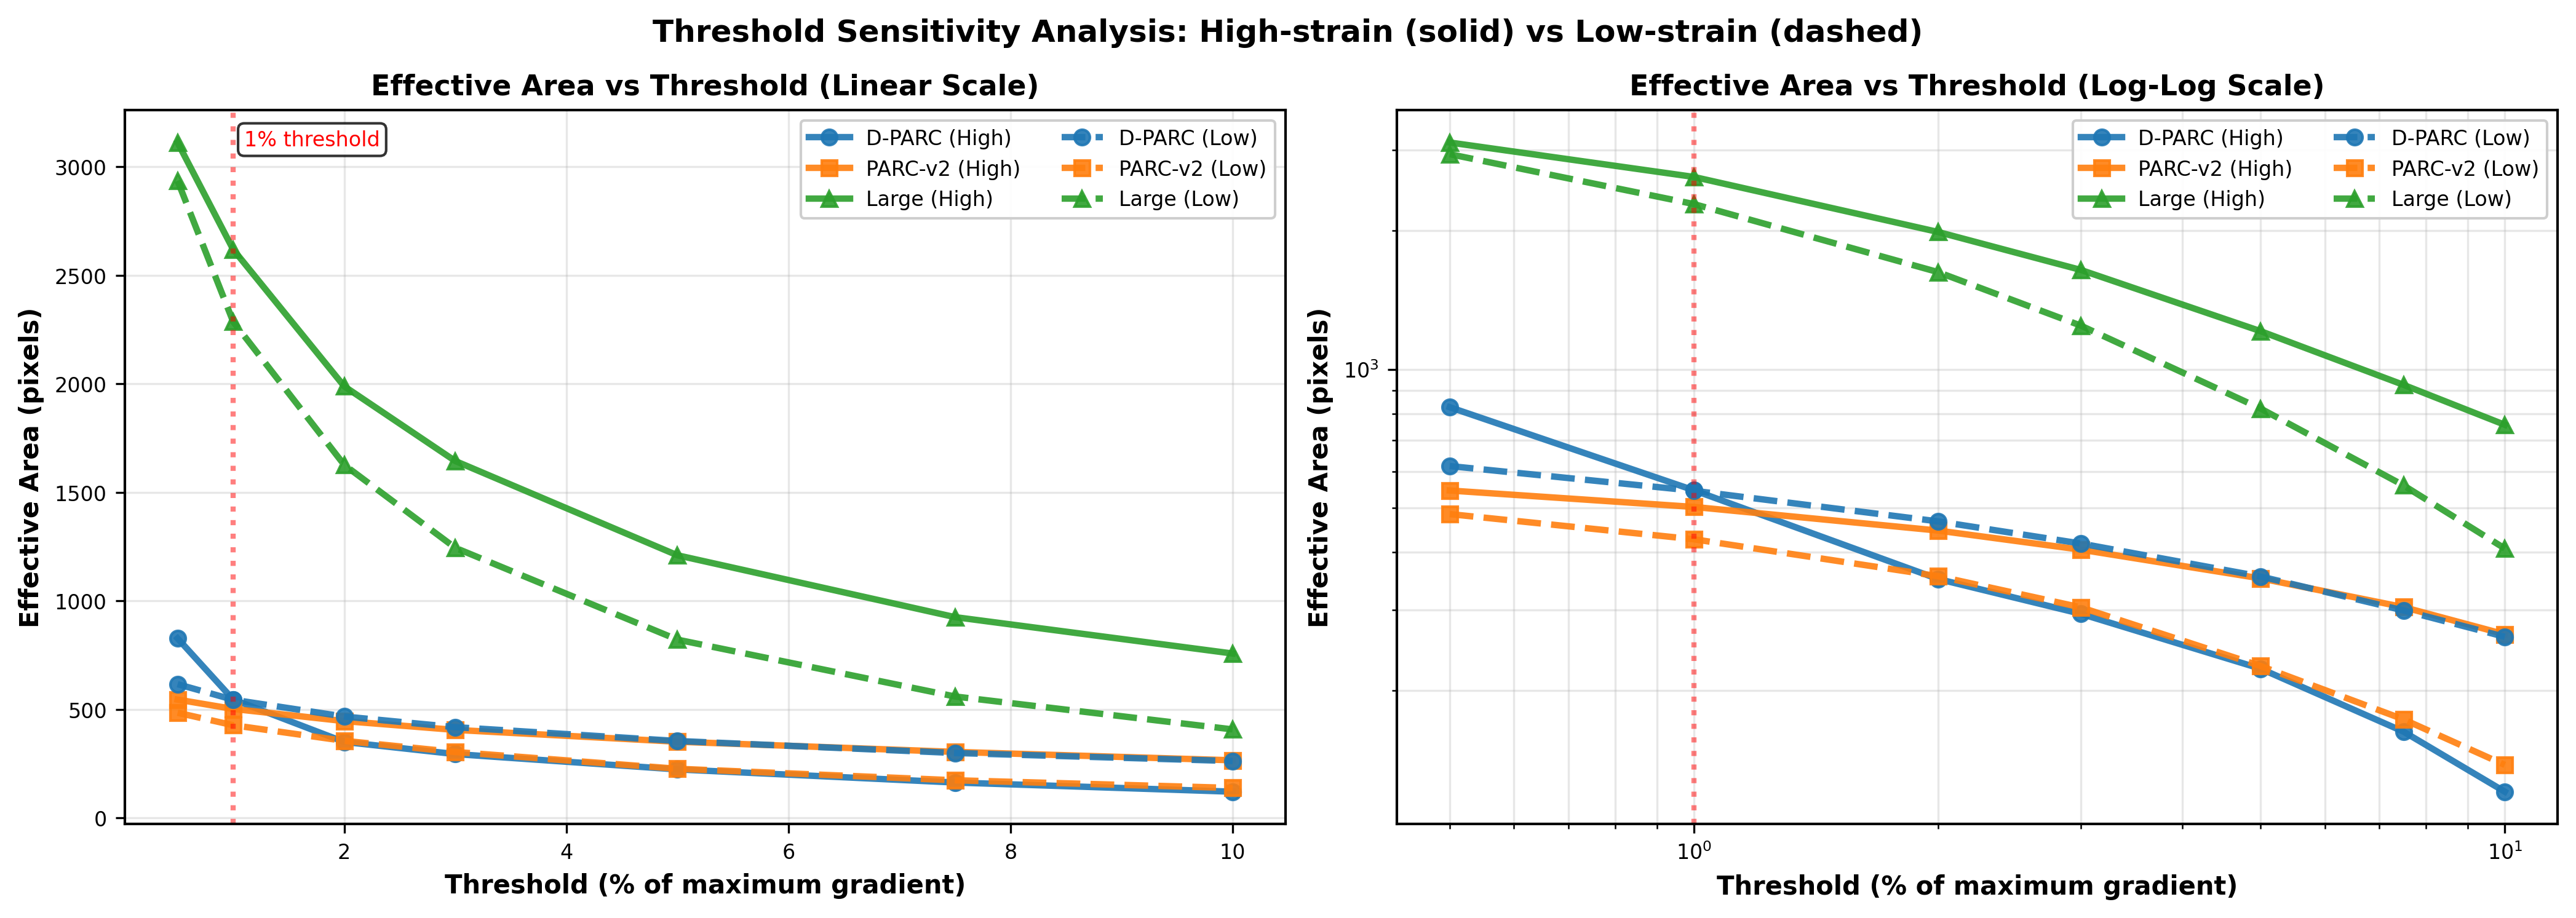


SUMMARY: AVERAGED METRICS AT 1% THRESHOLD

Region                             D-PARC                   PARC-v2                     Large
                   Area (px)     Sparsity    Area (px)     Sparsity    Area (px)     Sparsity
----------------------------------------------------------------------------------------------------
High strain             546   86.68%          502   87.74%         2619   36.05%
Low strain              544   86.71%          427   89.58%         2287   44.17%

✅ NOTE: Higher sparsity = more selective (fewer pixels activated)

GENERATING VISUALIZATION FOR REPRESENTATIVE POINTS

✓ Saved to: erf_multipoint_analysis_burgers/representative_erf_T47.png


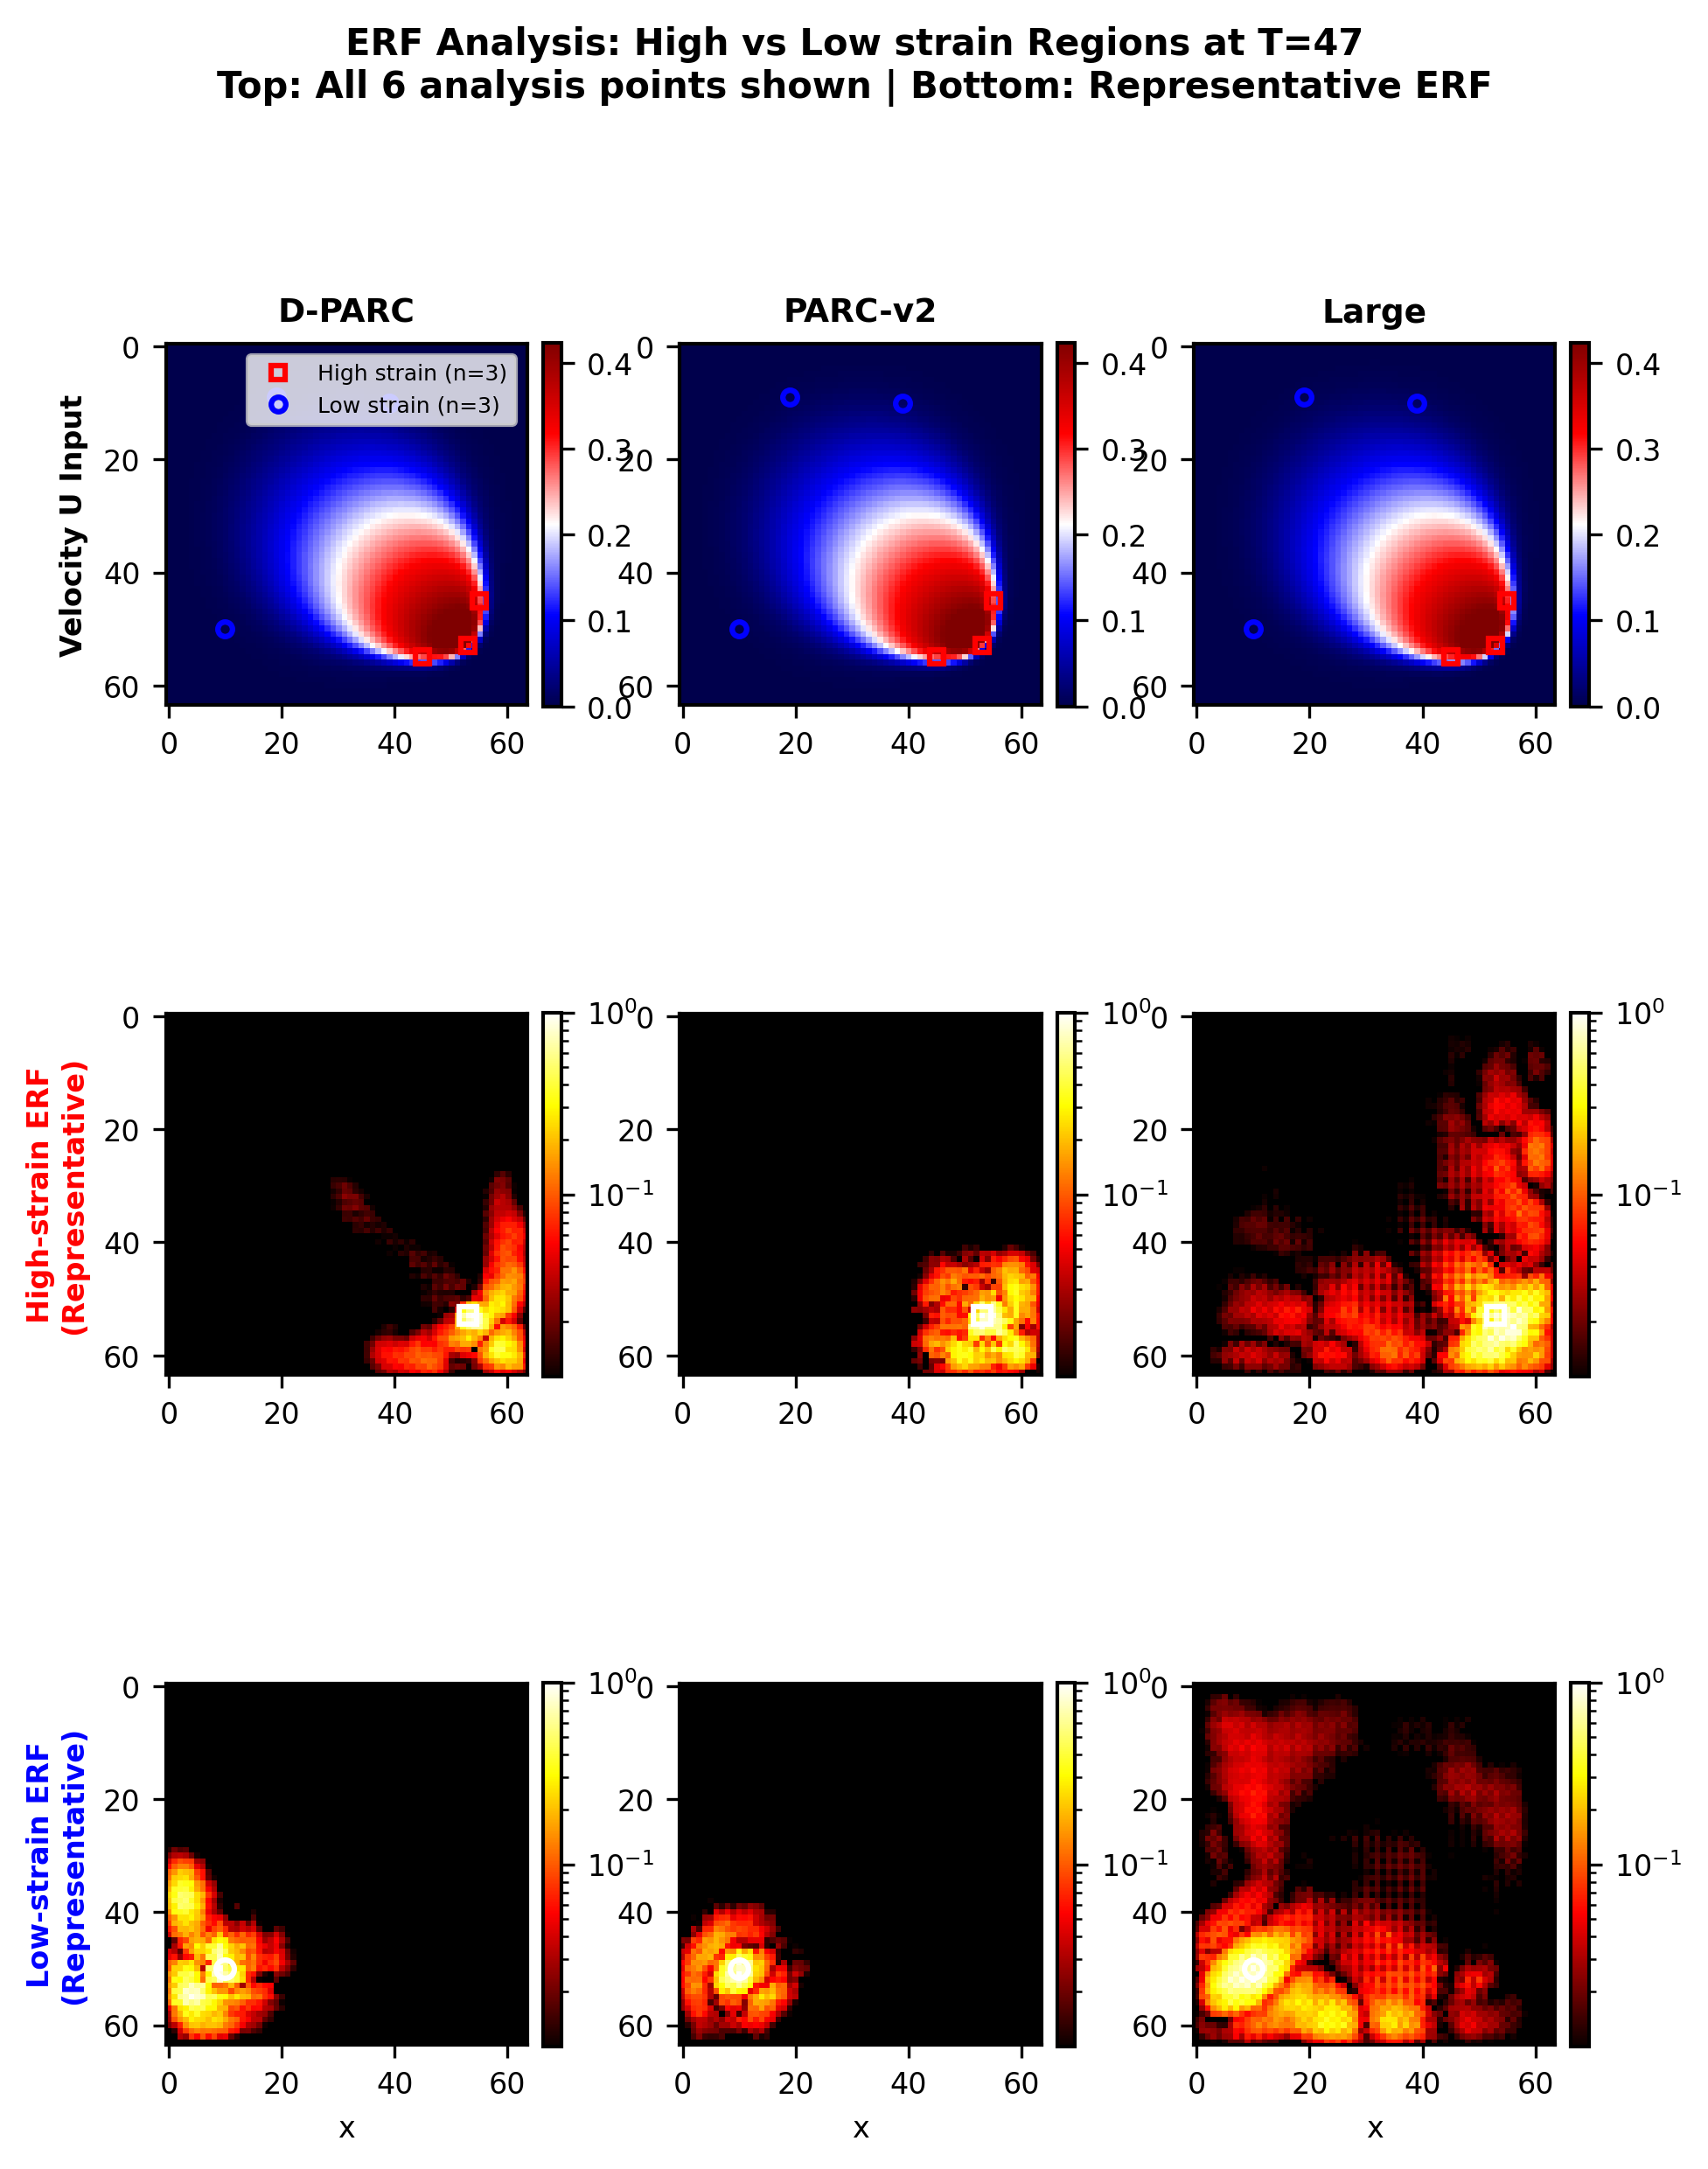


✓ MULTI-POINT ERF ANALYSIS COMPLETE! (BURGERS)

📊 Key Findings (Higher sparsity = more selective):

High-strain Regions (averaged over 3 points):
  D-PARC:  546 ± 53 px (sparsity: 86.68%)
  PARC-v2: 502 ± 14 px (sparsity: 87.74%)
  Large:   2619 ± 483 px (sparsity: 36.05%)

Low-strain Regions (averaged over 3 points):
  D-PARC:  544 ± 23 px (sparsity: 86.71%)
  PARC-v2: 427 ± 6 px (sparsity: 89.58%)
  Large:   2287 ± 168 px (sparsity: 44.17%)

📁 Outputs:
  - High-strain metrics: erf_multipoint_analysis_burgers/erf_averaged_high_strain_T47.csv
  - Low-strain metrics: erf_multipoint_analysis_burgers/erf_averaged_low_strain_T47.csv
  - Combined threshold plots: erf_multipoint_analysis_burgers/threshold_sensitivity_combined.png
  - Representative ERF: erf_multipoint_analysis_burgers/representative_erf_T47.png

💡 TIPS FOR BURGERS:
  - Adjust HIGH_strain_POINTS and LOW_strain_POINTS based on your data
  - High-strain = regions with strong velocity gradients (turbulent flow)
  - Low-strain =

In [7]:
################################################################################
# CELL: Multi-Point ERF Analysis - High vs Low strain Regions (Burgers)
################################################################################
"""
Multi-Point ERF Analysis for Burgers Equation

Analyzes ERF at 6 points (3 high-strain, 3 low-strain) at a specified timestep:
- Computes effective area and sparsity at multiple thresholds
- Averages metrics across high-strain and low-strain regions
- Generates visualizations for representative points
- Generates threshold sensitivity plots (linear + log)
- Exports metrics to CSV and prints to screen

Adapted from EM analysis code for fluid dynamics (Burgers equation).
Uses strain (gradient of velocity) as the distinguishing feature.
"""

import gc
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import json
import csv

print("\n" + "="*80)
print("MULTI-POINT ERF ANALYSIS - HIGH VS LOW strain (BURGERS)")
print("="*80)

# =============================================================================
# Configuration
# =============================================================================

ANALYZE_TIMESTEP = 47  # Which timestep to analyze (adjust as needed)
CHANNEL_TO_VISUALIZE = 1  # 0=Reynolds, 1=U, 2=V (U velocity for visualization)
VMIN_VIZ = None  # Auto-scale (or set explicitly, e.g., -1.0)
VMAX_VIZ = None  # Auto-scale (or set explicitly, e.g., 1.0)

# Define analysis points
# For Burgers: High-strain regions have strong velocity gradients
# You should adjust these points based on your data!
HIGH_strain_POINTS = [
    (53, 53),    # Point 1 - High strain (center region)
    (45, 55),    # Point 2 - High strain
    (55, 45),    # Point 3 - High strain
]

LOW_strain_POINTS = [
    (50, 10),    # Point 1 - Low strain (corner/edge)
    (9, 19),    # Point 2 - Low strain
    (10, 39),    # Point 3 - Low strain
]

# Thresholds to test
TEST_THRESHOLDS = [0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.10]

# Output configuration
OUTPUT_DIR = Path("erf_multipoint_analysis_burgers")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Configuration:")
print(f"  Timestep: T={ANALYZE_TIMESTEP}")
print(f"  High-strain points: {len(HIGH_strain_POINTS)}")
print(f"  Low-strain points: {len(LOW_strain_POINTS)}")
print(f"  Visualizing channel: {['Reynolds', 'Velocity U', 'Velocity V'][CHANNEL_TO_VISUALIZE]}")
print(f"  Output directory: {OUTPUT_DIR.resolve()}")

# =============================================================================
# Helper Functions
# =============================================================================

def set_plot_style():
    """Publication-ready style."""
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'font.size': 8,
        'axes.labelsize': 8,
        'axes.titlesize': 9,
        'legend.fontsize': 7,
        'figure.dpi': 300,
        'axes.linewidth': 1.0,
    })

def denormalize_channel(normalized_data, channel_idx, norm_params):
    """Denormalize a single channel back to physical units."""
    channel_min = norm_params["channel_min"][channel_idx]
    channel_max = norm_params["channel_max"][channel_idx]
    return normalized_data * (channel_max - channel_min) + channel_min

def compute_unet_erf_aggregate(model, input_state, output_point):
    """Compute UNet-only ERF aggregated across all output features."""
    # Find UNet in model structure
    unet = None
    possible_names = ['feature_extraction', 'feature_extractor', 'unet', 'network', 
                      'fe_network', 'encoder', 'feature_net']
    
    for attr_name in possible_names:
        if hasattr(model.differentiator, attr_name):
            unet = getattr(model.differentiator, attr_name)
            break
    
    if unet is None:
        raise AttributeError("Could not find UNet in model.differentiator")
    
    unet.eval()
    input_grad = input_state.detach().requires_grad_(True)
    
    with torch.set_grad_enabled(True):
        features = unet(input_grad)
        output_value = features[0, :, output_point[0], output_point[1]].sum()
    
    if input_grad.grad is not None:
        input_grad.grad.zero_()
    output_value.backward()
    
    if input_grad.grad is None:
        raise RuntimeError("Gradients are None!")
    
    gradients = input_grad.grad[0].detach().cpu().numpy()
    erf_map = np.abs(gradients)
    
    del input_grad, features, output_value
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    
    return erf_map

# =============================================================================
# Core ERF Computation for Multiple Points
# =============================================================================

def compute_erf_metrics_for_point(erf_map, thresholds):
    """
    Compute streamlined ERF metrics for a single point.
    
    Sparsity = percentage of domain NOT activated
    Higher sparsity = more selective
    
    Returns:
        dict: {threshold: {'area': X, 'sparsity': Y}}
    """
    erf_agg = np.sum(erf_map, axis=0)
    erf_norm = erf_agg / (erf_agg.max() + 1e-10)
    
    total_pixels = erf_norm.size
    
    results = {}
    for thresh in thresholds:
        erf_binary = (erf_norm > thresh).astype(float)
        activated = np.sum(erf_binary)
        
        # Sparsity = percentage NOT activated
        sparsity = (1 - activated / total_pixels) * 100
        
        results[thresh] = {
            'area': activated,
            'sparsity': sparsity
        }
    
    return results

def analyze_multiple_points(model, input_state, points, thresholds, point_type):
    """
    Analyze ERF at multiple points and return metrics.
    
    Args:
        model: PARC model
        input_state: Input state tensor [1, C, H, W]
        points: List of (y, x) coordinates
        thresholds: List of threshold values
        point_type: 'high_strain' or 'low_strain'
    
    Returns:
        dict: Metrics for each point and averages
    """
    print(f"\n  Analyzing {len(points)} {point_type} points...")
    
    results = {}
    
    for idx, point in enumerate(points):
        print(f"    Point {idx+1}/{len(points)}: {point}")
        
        # Compute ERF
        erf_map = compute_unet_erf_aggregate(model, input_state.clone(), point)
        
        # Compute metrics
        metrics = compute_erf_metrics_for_point(erf_map, thresholds)
        
        results[f'point_{idx+1}'] = {
            'coords': point,
            'erf_map': erf_map,
            'metrics': metrics
        }
    
    # Compute averages across all points
    avg_metrics = {}
    for thresh in thresholds:
        areas = [results[f'point_{i+1}']['metrics'][thresh]['area'] 
                for i in range(len(points))]
        sparsities = [results[f'point_{i+1}']['metrics'][thresh]['sparsity'] 
                     for i in range(len(points))]
        
        avg_metrics[thresh] = {
            'area_mean': np.mean(areas),
            'area_std': np.std(areas),
            'sparsity_mean': np.mean(sparsities),
            'sparsity_std': np.std(sparsities)
        }
    
    results['average'] = avg_metrics
    
    return results

# =============================================================================
# Get State at Target Timestep (from earlier cell)
# =============================================================================

def get_state_and_output(model, ic, t0, t1, target_timestep):
    """
    Run model forward to get state at timestep T and output at T+1.
    
    Args:
        model: PARC model
        ic: Initial condition [1, C, H, W]
        t0: Initial time scalar
        t1: Time array for future steps
        target_timestep: Which timestep to extract (0 = IC, 1 = first prediction, etc.)
    
    Returns:
        state_at_t: [1, C, H, W] state at target timestep
        output_at_t1: [1, C, H, W] output at target_timestep+1
    """
    model.eval()
    with torch.no_grad():
        if target_timestep == 0:
            # State is IC, output is first prediction
            state_at_t = ic.clone()
            t1_single = t1[:1]
            rollout = model(ic, t0, t1_single)
            output_at_t1 = rollout[0, :, :, :, :].clone()
        else:
            # Run forward to get both T and T+1
            t1_partial = t1[:target_timestep+2]
            rollout = model(ic, t0, t1_partial)
            state_at_t = rollout[target_timestep, :, :, :, :].clone()
            output_at_t1 = rollout[target_timestep+1, :, :, :, :].clone()
    
    return state_at_t, output_at_t1

print("\n" + "="*80)
print("LOADING DATA AND EXTRACTING STATES")
print("="*80)

# Load data for ERF analysis
print(f"\nLoading data for ERF analysis...")
ERF_FORWARD_STEPS = ANALYZE_TIMESTEP + 2  # Need T and T+1

erf_dataset = GenericPhysicsDataset(
    data_dirs=[EVAL_DATA_DIR],
    future_steps=ERF_FORWARD_STEPS,
    min_max_path=MIN_MAX_PATH
)

erf_loader = DataLoader(
    erf_dataset, 
    batch_size=1,  # ERF requires batch_size=1
    shuffle=False,
    num_workers=1, 
    pin_memory=(DEVICE=='cuda'),
    collate_fn=custom_collate_fn
)

erf_batch = next(iter(erf_loader))
erf_ic, erf_t0, erf_t1, _ = erf_batch
erf_ic = erf_ic.to(DEVICE)
erf_t0 = erf_t0.to(DEVICE)
erf_t1 = erf_t1.to(DEVICE)

print(f"✓ ERF data loaded. Initial condition shape: {erf_ic.shape}")

# Load normalization parameters
with open(MIN_MAX_PATH, 'r') as f:
    norm_params = json.load(f)

print(f"\nExtracting states at T={ANALYZE_TIMESTEP}...")

state_at_t_deform, output_at_t1_deform = get_state_and_output(
    model_deform, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP
)
state_at_t_standard, output_at_t1_standard = get_state_and_output(
    model_standard, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP
)
state_at_t_large, output_at_t1_large = get_state_and_output(
    model_large, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP
)

print(f"✓ States at T={ANALYZE_TIMESTEP} extracted. Shape: {state_at_t_deform.shape}")

# =============================================================================
# Analyze All Models and Points
# =============================================================================

print("\n" + "="*80)
print("COMPUTING ERF FOR ALL POINTS AND MODELS")
print("="*80)

# Storage for results
all_results = {
    'D-PARC': {'high_strain': None, 'low_strain': None},
    'PARC-v2': {'high_strain': None, 'low_strain': None},
    'Large': {'high_strain': None, 'low_strain': None}
}

# D-PARC
print("\n[1/3] D-PARC")
all_results['D-PARC']['high_strain'] = analyze_multiple_points(
    model_deform, state_at_t_deform, HIGH_strain_POINTS, TEST_THRESHOLDS, 'high_strain'
)
all_results['D-PARC']['low_strain'] = analyze_multiple_points(
    model_deform, state_at_t_deform, LOW_strain_POINTS, TEST_THRESHOLDS, 'low_strain'
)

# PARC-v2
print("\n[2/3] PARC-v2")
all_results['PARC-v2']['high_strain'] = analyze_multiple_points(
    model_standard, state_at_t_standard, HIGH_strain_POINTS, TEST_THRESHOLDS, 'high_strain'
)
all_results['PARC-v2']['low_strain'] = analyze_multiple_points(
    model_standard, state_at_t_standard, LOW_strain_POINTS, TEST_THRESHOLDS, 'low_strain'
)

# Large
print("\n[3/3] Large")
all_results['Large']['high_strain'] = analyze_multiple_points(
    model_large, state_at_t_large, HIGH_strain_POINTS, TEST_THRESHOLDS, 'high_strain'
)
all_results['Large']['low_strain'] = analyze_multiple_points(
    model_large, state_at_t_large, LOW_strain_POINTS, TEST_THRESHOLDS, 'low_strain'
)

print("\n✓ ERF computation complete for all points!")

# =============================================================================
# Export Averaged Metrics to CSV and Print to Screen
# =============================================================================

print("\n" + "="*80)
print("EXPORTING AVERAGED METRICS")
print("="*80)

# Export and print high-strain averages
csv_high = OUTPUT_DIR / f'erf_averaged_high_strain_T{ANALYZE_TIMESTEP}.csv'
print(f"\n📊 HIGH-strain REGION (averaged over {len(HIGH_strain_POINTS)} points)")
print(f"{'Threshold':<12} {'D-PARC':>30} {'PARC-v2':>30} {'Large':>30}")
print(f"{'(% of max)':<12} {'Area (mean±std)':>15} {'Sparsity':>15} {'Area (mean±std)':>15} {'Sparsity':>15} {'Area (mean±std)':>15} {'Sparsity':>15}")
print("-" * 115)

with open(csv_high, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Threshold (%)', 
                    'D-PARC Area (mean±std)', 'D-PARC Sparsity (mean±std)',
                    'PARC-v2 Area (mean±std)', 'PARC-v2 Sparsity (mean±std)',
                    'Large Area (mean±std)', 'Large Sparsity (mean±std)'])
    
    for thresh in TEST_THRESHOLDS:
        row = [f"{thresh*100:.1f}"]
        
        # Collect data for printing
        print_data = [f"{thresh*100:>6.1f}%      "]
        
        for model in ['D-PARC', 'PARC-v2', 'Large']:
            avg = all_results[model]['high_strain']['average'][thresh]
            row.append(f"{avg['area_mean']:.1f}±{avg['area_std']:.1f}")
            row.append(f"{avg['sparsity_mean']:.2f}±{avg['sparsity_std']:.2f}")
            
            print_data.append(f"{avg['area_mean']:>7.0f}±{avg['area_std']:<6.0f}")
            print_data.append(f"{avg['sparsity_mean']:>6.2f}±{avg['sparsity_std']:<6.2f}")
        
        writer.writerow(row)
        print(''.join(print_data))

print(f"\n✓ Saved to: {csv_high}")

# Export and print low-strain averages
csv_low = OUTPUT_DIR / f'erf_averaged_low_strain_T{ANALYZE_TIMESTEP}.csv'
print(f"\n📊 LOW-strain REGION (averaged over {len(LOW_strain_POINTS)} points)")
print(f"{'Threshold':<12} {'D-PARC':>30} {'PARC-v2':>30} {'Large':>30}")
print(f"{'(% of max)':<12} {'Area (mean±std)':>15} {'Sparsity':>15} {'Area (mean±std)':>15} {'Sparsity':>15} {'Area (mean±std)':>15} {'Sparsity':>15}")
print("-" * 115)

with open(csv_low, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Threshold (%)', 
                    'D-PARC Area (mean±std)', 'D-PARC Sparsity (mean±std)',
                    'PARC-v2 Area (mean±std)', 'PARC-v2 Sparsity (mean±std)',
                    'Large Area (mean±std)', 'Large Sparsity (mean±std)'])
    
    for thresh in TEST_THRESHOLDS:
        row = [f"{thresh*100:.1f}"]
        
        # Collect data for printing
        print_data = [f"{thresh*100:>6.1f}%      "]
        
        for model in ['D-PARC', 'PARC-v2', 'Large']:
            avg = all_results[model]['low_strain']['average'][thresh]
            row.append(f"{avg['area_mean']:.1f}±{avg['area_std']:.1f}")
            row.append(f"{avg['sparsity_mean']:.2f}±{avg['sparsity_std']:.2f}")
            
            print_data.append(f"{avg['area_mean']:>7.0f}±{avg['area_std']:<6.0f}")
            print_data.append(f"{avg['sparsity_mean']:>6.2f}±{avg['sparsity_std']:<6.2f}")
        
        writer.writerow(row)
        print(''.join(print_data))

print(f"\n✓ Saved to: {csv_low}")

# =============================================================================
# Threshold Sensitivity Plots (Combined High/Low strain)
# =============================================================================

print("\n" + "="*80)
print("GENERATING THRESHOLD SENSITIVITY PLOTS")
print("="*80)

def plot_threshold_sensitivity_combined(all_results, thresholds, output_dir):
    """
    Plot threshold sensitivity with high-strain and low-strain on same plots.
    Uses solid lines for high-strain, dashed lines for low-strain.
    """
    set_plot_style()
    
    # Extract averaged areas for each model and region
    high_areas = {
        'D-PARC': [all_results['D-PARC']['high_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARC-v2': [all_results['PARC-v2']['high_strain']['average'][t]['area_mean'] for t in thresholds],
        'Large': [all_results['Large']['high_strain']['average'][t]['area_mean'] for t in thresholds]
    }
    
    low_areas = {
        'D-PARC': [all_results['D-PARC']['low_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARC-v2': [all_results['PARC-v2']['low_strain']['average'][t]['area_mean'] for t in thresholds],
        'Large': [all_results['Large']['low_strain']['average'][t]['area_mean'] for t in thresholds]
    }
    
    thresh_percent = np.array(thresholds) * 100
    
    # Create figure with 1x2 subplots (linear + log-log)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Define colors and markers for each model
    model_styles = {
        'D-PARC': {'color': 'C0', 'marker': 'o'},
        'PARC-v2': {'color': 'C1', 'marker': 's'},
        'Large': {'color': 'C2', 'marker': '^'}
    }
    
    line_props_solid = {'linewidth': 2.5, 'markersize': 6, 'alpha': 0.9, 'linestyle': '-'}
    line_props_dashed = {'linewidth': 2.5, 'markersize': 6, 'alpha': 0.9, 'linestyle': '--'}
    
    # ========== LINEAR SCALE ==========
    ax = axes[0]
    
    # Plot high-strain (solid lines)
    for model in ['D-PARC', 'PARC-v2', 'Large']:
        ax.plot(thresh_percent, high_areas[model], 
               label=f'{model} (High)', 
               color=model_styles[model]['color'],
               marker=model_styles[model]['marker'],
               **line_props_solid)
    
    # Plot low-strain (dashed lines)
    for model in ['D-PARC', 'PARC-v2', 'Large']:
        ax.plot(thresh_percent, low_areas[model], 
               label=f'{model} (Low)', 
               color=model_styles[model]['color'],
               marker=model_styles[model]['marker'],
               **line_props_dashed)
    
    ax.axvline(1.0, color='red', linestyle=':', alpha=0.5, linewidth=2)
    ax.text(1.1, ax.get_ylim()[1]*0.95, '1% threshold', 
           fontsize=8, color='red', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Threshold (% of maximum gradient)', fontweight='bold', fontsize=10)
    ax.set_ylabel('Effective Area (pixels)', fontweight='bold', fontsize=10)
    ax.set_title('Effective Area vs Threshold (Linear Scale)', fontweight='bold', fontsize=11)
    ax.legend(framealpha=0.95, fontsize=8, ncol=2, loc='best')
    ax.grid(True, alpha=0.3)
    
    # ========== LOG-LOG SCALE ==========
    ax = axes[1]
    
    # Plot high-strain (solid lines)
    for model in ['D-PARC', 'PARC-v2', 'Large']:
        ax.loglog(thresh_percent, high_areas[model], 
                 label=f'{model} (High)', 
                 color=model_styles[model]['color'],
                 marker=model_styles[model]['marker'],
                 **line_props_solid)
    
    # Plot low-strain (dashed lines)
    for model in ['D-PARC', 'PARC-v2', 'Large']:
        ax.loglog(thresh_percent, low_areas[model], 
                 label=f'{model} (Low)', 
                 color=model_styles[model]['color'],
                 marker=model_styles[model]['marker'],
                 **line_props_dashed)
    
    ax.axvline(1.0, color='red', linestyle=':', alpha=0.5, linewidth=2)
    
    ax.set_xlabel('Threshold (% of maximum gradient)', fontweight='bold', fontsize=10)
    ax.set_ylabel('Effective Area (pixels)', fontweight='bold', fontsize=10)
    ax.set_title('Effective Area vs Threshold (Log-Log Scale)', fontweight='bold', fontsize=11)
    ax.legend(framealpha=0.95, fontsize=8, ncol=2, loc='best')
    ax.grid(True, alpha=0.3, which='both')
    
    plt.suptitle('Threshold Sensitivity Analysis: High-strain (solid) vs Low-strain (dashed)',
                fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    output_path = output_dir / 'threshold_sensitivity_combined.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved to: {output_path}")
    plt.show()
    plt.close()
    gc.collect()

# Generate plots
plot_threshold_sensitivity_combined(all_results, TEST_THRESHOLDS, OUTPUT_DIR)

# =============================================================================
# Print Summary Table
# =============================================================================

print("\n" + "="*80)
print("SUMMARY: AVERAGED METRICS AT 1% THRESHOLD")
print("="*80)

print(f"\n{'Region':<15} {'D-PARC':>25} {'PARC-v2':>25} {'Large':>25}")
print(f"{'':^15} {'Area (px)':>12} {'Sparsity':>12} {'Area (px)':>12} {'Sparsity':>12} {'Area (px)':>12} {'Sparsity':>12}")
print("-" * 100)

thresh_1pct = 0.01

# High strain
high_d = all_results['D-PARC']['high_strain']['average'][thresh_1pct]
high_s = all_results['PARC-v2']['high_strain']['average'][thresh_1pct]
high_l = all_results['Large']['high_strain']['average'][thresh_1pct]

print(f"{'High strain':<15} "
      f"{high_d['area_mean']:>11.0f}  {high_d['sparsity_mean']:>6.2f}%  "
      f"{high_s['area_mean']:>11.0f}  {high_s['sparsity_mean']:>6.2f}%  "
      f"{high_l['area_mean']:>11.0f}  {high_l['sparsity_mean']:>6.2f}%")

# Low strain
low_d = all_results['D-PARC']['low_strain']['average'][thresh_1pct]
low_s = all_results['PARC-v2']['low_strain']['average'][thresh_1pct]
low_l = all_results['Large']['low_strain']['average'][thresh_1pct]

print(f"{'Low strain':<15} "
      f"{low_d['area_mean']:>11.0f}  {low_d['sparsity_mean']:>6.2f}%  "
      f"{low_s['area_mean']:>11.0f}  {low_s['sparsity_mean']:>6.2f}%  "
      f"{low_l['area_mean']:>11.0f}  {low_l['sparsity_mean']:>6.2f}%")

print("\n✅ NOTE: Higher sparsity = more selective (fewer pixels activated)")

# =============================================================================
# Visualization: Representative Point from Each Region (ALL 6 POINTS SHOWN)
# =============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATION FOR REPRESENTATIVE POINTS")
print("="*80)

def plot_representative_erf_all_points(
    state_d, state_s, state_l,
    erf_high_d, erf_high_s, erf_high_l, point_high,
    erf_low_d, erf_low_s, erf_low_l, point_low,
    all_high_points, all_low_points,
    norm_params, timestep, channel_idx, vmin, vmax, output_path
):
    """
    Plot ERF for one representative high-strain and one low-strain point.
    Shows ALL 6 analysis points on the velocity input row.
    """
    set_plot_style()
    
    # Channel names and colormaps
    channel_names = ['Reynolds Number', 'Velocity U', 'Velocity V']
    channel_cmaps = ['viridis', 'seismic', 'seismic']
    
    # Denormalize velocity field
    state_d_np = denormalize_channel(state_d[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_s_np = denormalize_channel(state_s[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_l_np = denormalize_channel(state_l[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    
    # Auto-scale if needed
    if vmin is None or vmax is None:
        all_data = np.concatenate([state_d_np.flatten(), state_s_np.flatten(), state_l_np.flatten()])
        vmin = np.percentile(all_data, 1)
        vmax = np.percentile(all_data, 99)
    
    # Process ERFs for representative points
    def process_erf(erf_map):
        erf_agg = np.sum(erf_map, axis=0)
        erf_norm = erf_agg / (erf_agg.max() + 1e-10)
        threshold = 0.01
        erf_masked = np.where(erf_norm > threshold, erf_norm, np.nan)
        return erf_masked
    
    erf_high_d_masked = process_erf(erf_high_d)
    erf_high_s_masked = process_erf(erf_high_s)
    erf_high_l_masked = process_erf(erf_high_l)
    
    erf_low_d_masked = process_erf(erf_low_d)
    erf_low_s_masked = process_erf(erf_low_s)
    erf_low_l_masked = process_erf(erf_low_l)
    
    # Compute shared vmin for log scale
    def safe_nanmin(arr, default=1e-3):
        valid = arr[~np.isnan(arr)]
        return valid.min() if len(valid) > 0 else default
    
    vmin_shared = min([
        safe_nanmin(erf_high_d_masked), safe_nanmin(erf_high_s_masked), safe_nanmin(erf_high_l_masked),
        safe_nanmin(erf_low_d_masked), safe_nanmin(erf_low_s_masked), safe_nanmin(erf_low_l_masked)
    ])
    
    # Create figure
    fig = plt.figure(figsize=(7, 9))
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)
    
    # Marker styles
    high_marker_props = {'marker': 's', 'markersize': 4, 'markerfacecolor': 'none', 
                         'markeredgecolor': 'red', 'markeredgewidth': 1.5, 'linestyle': 'none'}
    low_marker_props = {'marker': 'o', 'markersize': 4, 'markerfacecolor': 'none', 
                        'markeredgecolor': 'blue', 'markeredgewidth': 1.5, 'linestyle': 'none'}
    
    # Row 0: Velocity input with ALL 6 points shown
    for col, (vel_data, title) in enumerate([
        (state_d_np, 'D-PARC'),
        (state_s_np, 'PARC-v2'),
        (state_l_np, 'Large')
    ]):
        ax = fig.add_subplot(gs[0, col])
        im = ax.imshow(vel_data, cmap=channel_cmaps[channel_idx], vmin=vmin, vmax=vmax)
        
        # Plot ALL high-strain points
        for pt in all_high_points:
            ax.plot(pt[1], pt[0], **high_marker_props)
        
        # Plot ALL low-strain points
        for pt in all_low_points:
            ax.plot(pt[1], pt[0], **low_marker_props)
        
        ax.set_title(title, fontweight='bold')
        
        if col == 0:
            ax.set_ylabel(f'{channel_names[channel_idx]} Input', fontweight='bold')
            # Add legend
            from matplotlib.lines import Line2D
            legend_elements = [
                Line2D([0], [0], **high_marker_props, label=f'High strain (n={len(all_high_points)})'),
                Line2D([0], [0], **low_marker_props, label=f'Low strain (n={len(all_low_points)})')
            ]
            ax.legend(handles=legend_elements, fontsize=6, loc='upper right')
        
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Row 1: High-strain ERF (representative point only)
    for col, (erf_data, title) in enumerate([
        (erf_high_d_masked, 'D-PARC'),
        (erf_high_s_masked, 'PARC-v2'),
        (erf_high_l_masked, 'Large')
    ]):
        ax = fig.add_subplot(gs[1, col])
        ax.set_facecolor('black')
        im = ax.imshow(erf_data, cmap='hot',
                      norm=LogNorm(vmin=vmin_shared, vmax=1.0))
        ax.plot(point_high[1], point_high[0], 's', markersize=5,
               markerfacecolor='none', markeredgecolor='white', markeredgewidth=1.5)
        if col == 0:
            ax.set_ylabel('High-strain ERF\n(Representative)', fontweight='bold', color='red')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Row 2: Low-strain ERF (representative point only)
    for col, (erf_data, title) in enumerate([
        (erf_low_d_masked, 'D-PARC'),
        (erf_low_s_masked, 'PARC-v2'),
        (erf_low_l_masked, 'Large')
    ]):
        ax = fig.add_subplot(gs[2, col])
        ax.set_facecolor('black')
        im = ax.imshow(erf_data, cmap='hot',
                      norm=LogNorm(vmin=vmin_shared, vmax=1.0))
        ax.plot(point_low[1], point_low[0], 'o', markersize=5,
               markerfacecolor='none', markeredgecolor='white', markeredgewidth=1.5)
        ax.set_xlabel('x')
        if col == 0:
            ax.set_ylabel('Low-strain ERF\n(Representative)', fontweight='bold', color='blue')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.suptitle(f'ERF Analysis: High vs Low strain Regions at T={timestep}\n'
                 f'Top: All {len(all_high_points)+len(all_low_points)} analysis points shown | Bottom: Representative ERF',
                fontsize=10, fontweight='bold', y=0.99)
    
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"\n✓ Saved to: {output_path}")
    plt.show()
    plt.close()
    gc.collect()

# Generate visualization using first point from each region
plot_representative_erf_all_points(
    state_at_t_deform, state_at_t_standard, state_at_t_large,
    all_results['D-PARC']['high_strain']['point_1']['erf_map'],
    all_results['PARC-v2']['high_strain']['point_1']['erf_map'],
    all_results['Large']['high_strain']['point_1']['erf_map'],
    HIGH_strain_POINTS[0],
    all_results['D-PARC']['low_strain']['point_1']['erf_map'],
    all_results['PARC-v2']['low_strain']['point_1']['erf_map'],
    all_results['Large']['low_strain']['point_1']['erf_map'],
    LOW_strain_POINTS[0],
    HIGH_strain_POINTS,  # Pass all high-strain points
    LOW_strain_POINTS,   # Pass all low-strain points
    norm_params, ANALYZE_TIMESTEP, CHANNEL_TO_VISUALIZE, VMIN_VIZ, VMAX_VIZ,
    OUTPUT_DIR / f'representative_erf_T{ANALYZE_TIMESTEP}.png'
)

# =============================================================================
# Summary
# =============================================================================

print("\n" + "="*80)
print("✓ MULTI-POINT ERF ANALYSIS COMPLETE! (BURGERS)")
print("="*80)

print("\n📊 Key Findings (Higher sparsity = more selective):")
print(f"\nHigh-strain Regions (averaged over {len(HIGH_strain_POINTS)} points):")
print(f"  D-PARC:  {high_d['area_mean']:.0f} ± {high_d['area_std']:.0f} px (sparsity: {high_d['sparsity_mean']:.2f}%)")
print(f"  PARC-v2: {high_s['area_mean']:.0f} ± {high_s['area_std']:.0f} px (sparsity: {high_s['sparsity_mean']:.2f}%)")
print(f"  Large:   {high_l['area_mean']:.0f} ± {high_l['area_std']:.0f} px (sparsity: {high_l['sparsity_mean']:.2f}%)")

print(f"\nLow-strain Regions (averaged over {len(LOW_strain_POINTS)} points):")
print(f"  D-PARC:  {low_d['area_mean']:.0f} ± {low_d['area_std']:.0f} px (sparsity: {low_d['sparsity_mean']:.2f}%)")
print(f"  PARC-v2: {low_s['area_mean']:.0f} ± {low_s['area_std']:.0f} px (sparsity: {low_s['sparsity_mean']:.2f}%)")
print(f"  Large:   {low_l['area_mean']:.0f} ± {low_l['area_std']:.0f} px (sparsity: {low_l['sparsity_mean']:.2f}%)")

print("\n📁 Outputs:")
print(f"  - High-strain metrics: {csv_high}")
print(f"  - Low-strain metrics: {csv_low}")
print(f"  - Combined threshold plots: {OUTPUT_DIR / 'threshold_sensitivity_combined.png'}")
print(f"  - Representative ERF: {OUTPUT_DIR / f'representative_erf_T{ANALYZE_TIMESTEP}.png'}")

print("\n💡 TIPS FOR BURGERS:")
print("  - Adjust HIGH_strain_POINTS and LOW_strain_POINTS based on your data")
print("  - High-strain = regions with strong velocity gradients (turbulent flow)")
print("  - Low-strain = regions with smooth, laminar flow")
print("  - You may want to compute actual strain (∂u/∂y - ∂v/∂x) to identify points")
print("  - Try different timesteps to see how ERF evolves during simulation")

print("\n" + "="*80)


MULTI-POINT ERF ANALYSIS - RELATIVE SPATIAL SPARSITY (BURGERS)

✓ Configuration:
  Timestep: T=47
  Visualizing: Channel 1 (Velocity U)
  PARCv2 TRF Area: 324 pixels

LOADING DATA AND EXTRACTING STATES

Loading data for ERF analysis...


Listing samples: 100%|██████████| 378/378 [00:01<00:00, 273.75it/s]



Extracting states at T=47...

COMPUTING ERF WITH RELATIVE SPARSITY
Global Domain Size (HxW): 64x64 = 4096 pixels
-> PARCv2 Denominator: 324 px

[1/3] D-PARC

  Analyzing 3 high_strain points...
  -> Using Denominator: 4096 pixels

  Analyzing 3 low_strain points...
  -> Using Denominator: 4096 pixels

[2/3] PARC-v2

  Analyzing 3 high_strain points...
  -> Using Denominator: 324 pixels

  Analyzing 3 low_strain points...
  -> Using Denominator: 324 pixels

[3/3] Large

  Analyzing 3 high_strain points...
  -> Using Denominator: 4096 pixels

  Analyzing 3 low_strain points...
  -> Using Denominator: 4096 pixels

EXPORTING RELATIVE SPARSITY METRICS

📊 HIGH-GRADIENT (SHOCK) REGION (Relative Sparsity)
Threshold                            D-PARC                        PARC-v2                          Large
(% of max)              Area   Rel. Sparsity            Area   Rel. Sparsity            Area   Rel. Sparsity
-----------------------------------------------------------------------------

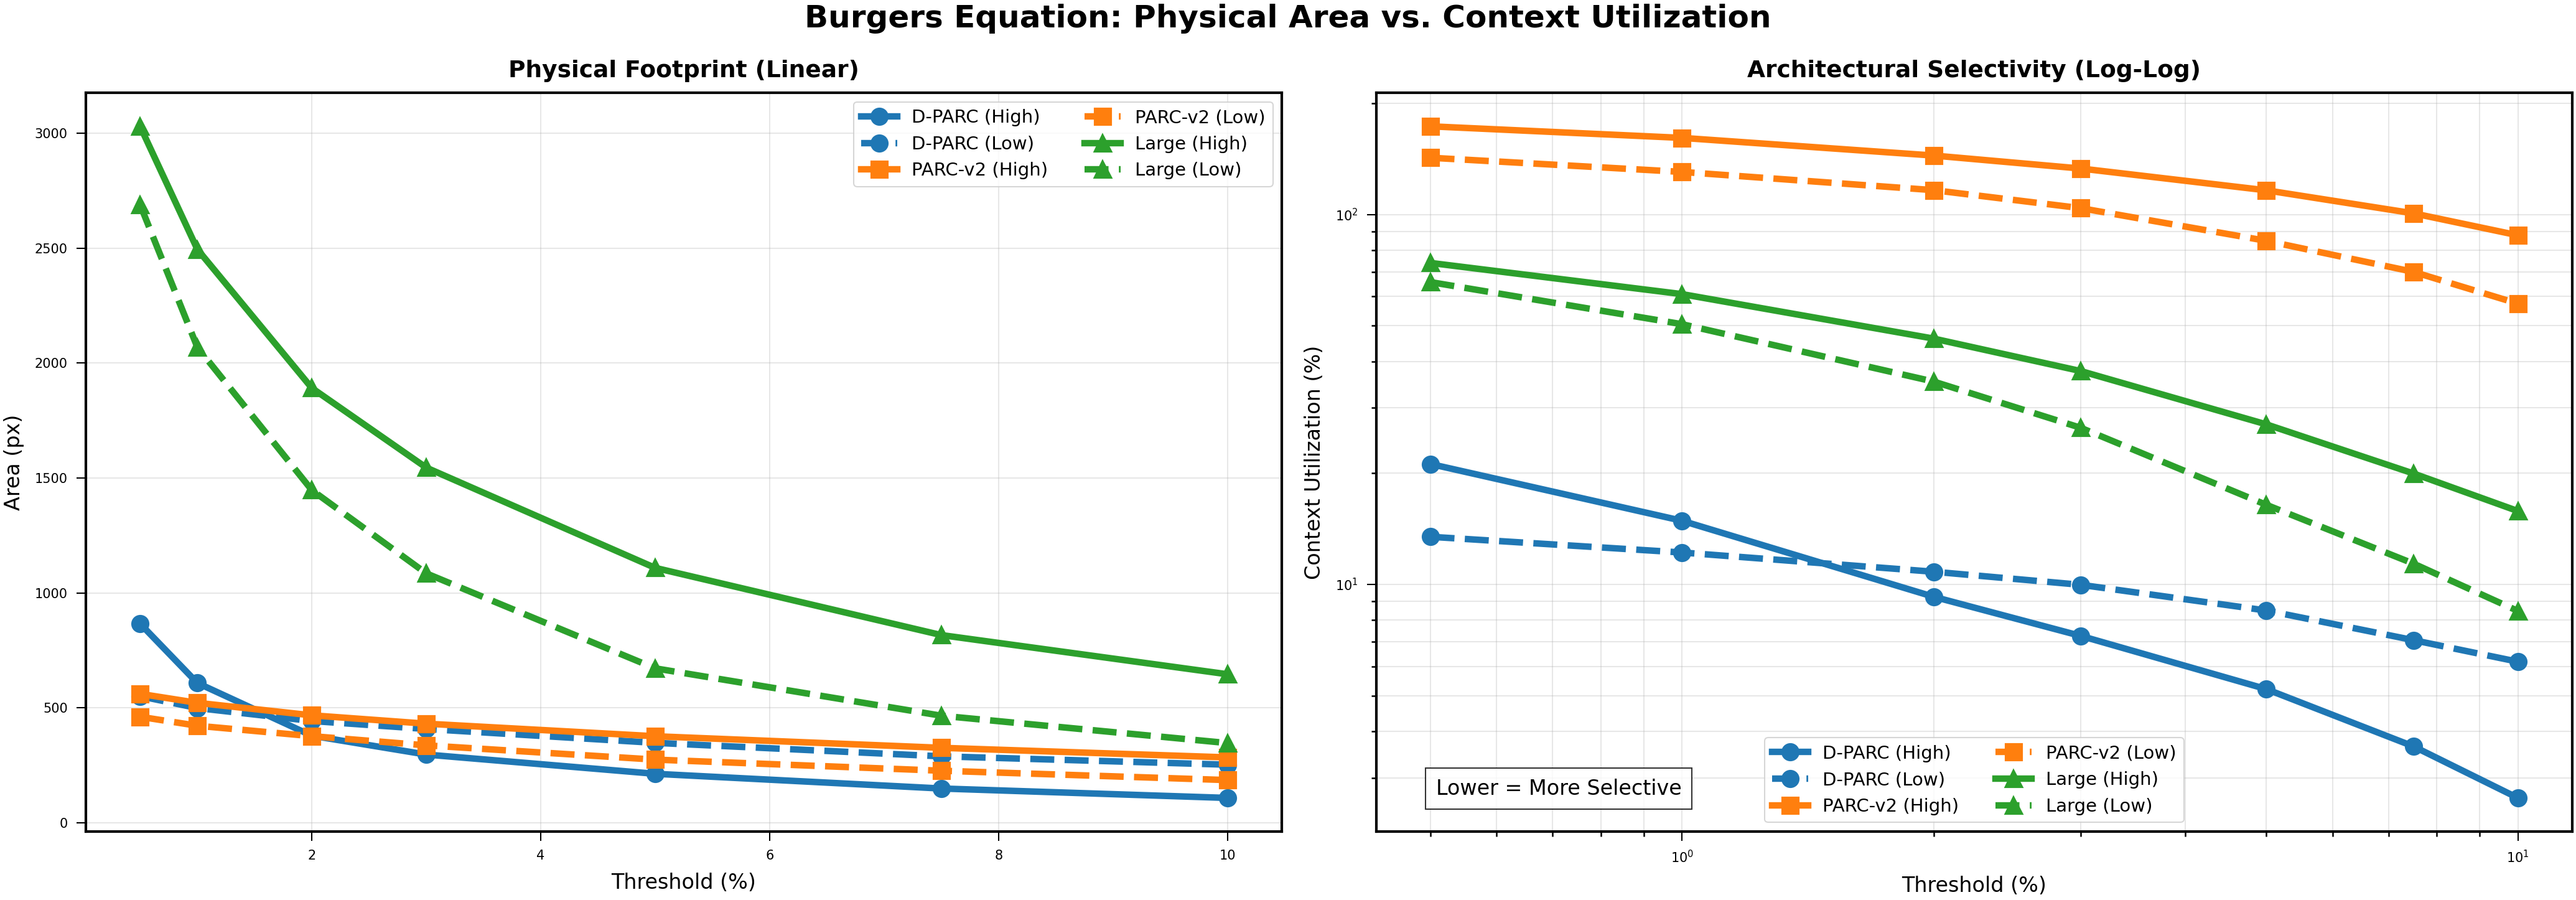


GENERATING VISUALIZATION


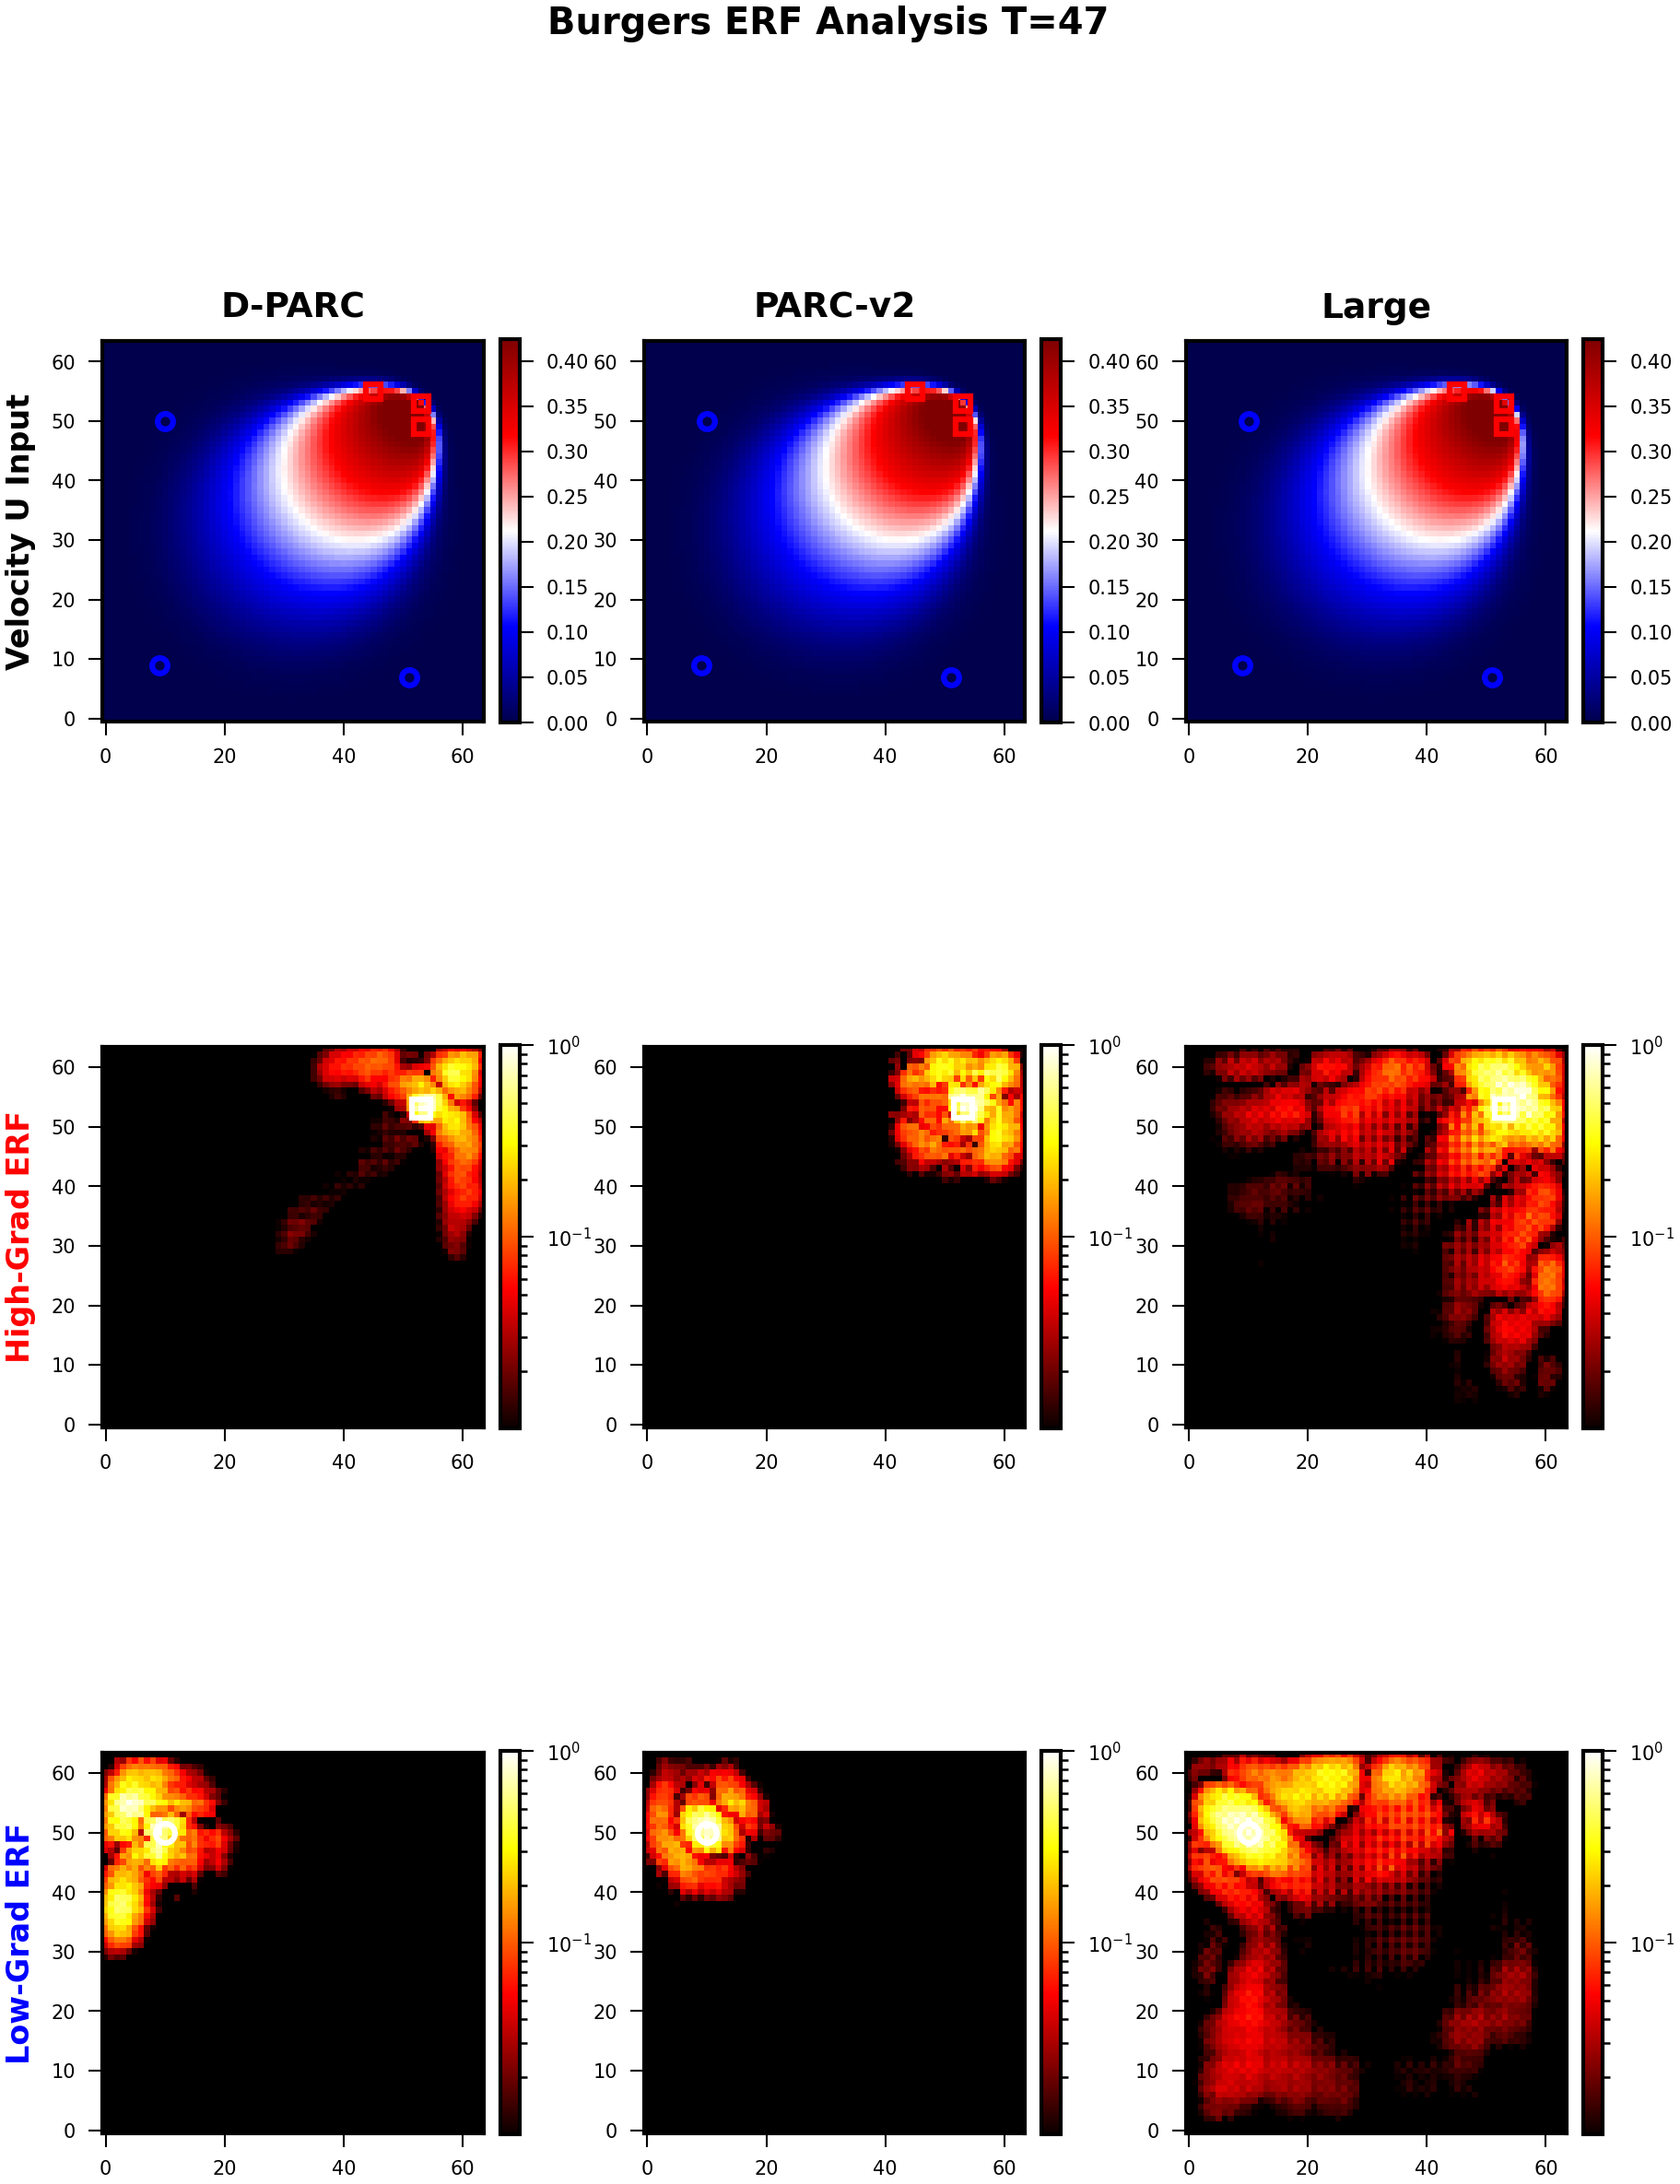

In [30]:
################################################################################
# CELL: Multi-Point ERF Analysis - Relative Spatial Sparsity (Burgers V4.3)
################################################################################
"""
Multi-Point ERF Analysis for Burgers Equation (Context Utilization)

V4.3 Features:
- Relative Sparsity = (1 - Area / Denominator) * 100%
- PARCv2 Denominator = min(TRF, HxW) (Handles small grid sizes correctly)
- D-PARC Denominator = HxW
- Context Utilization Log-Log Plots
"""

import gc
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import json
import csv

print("\n" + "="*80)
print("MULTI-POINT ERF ANALYSIS - RELATIVE SPATIAL SPARSITY (BURGERS)")
print("="*80)

# =============================================================================
# Configuration
# =============================================================================

ANALYZE_TIMESTEP = 47  # Shock formation / interaction phase
CHANNEL_TO_VISUALIZE = 1  # 1 = Velocity U
VMIN_VIZ = None  # Auto-scale
VMAX_VIZ = None  # Auto-scale

# Analysis Points (Specific to Burgers Shock/Smooth regions)
HIGH_STRAIN_POINTS = [
    (53, 53),    # Point 1 - High gradient (shock)
    (49, 53),    # Point 2 - High gradient
    (55, 45),    # Point 3 - High gradient
]

LOW_STRAIN_POINTS = [
    (50, 10),    # Point 1 - Low gradient (smooth)
    (9, 9),     # Point 2 - Low gradient
    (7, 51),    # Point 3 - Low gradient
]


# Thresholds
TEST_THRESHOLDS = [0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.10]

# Output
OUTPUT_DIR = Path("erf_multipoint_analysis_burgers")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- DENOMINATOR CONFIGURATION ---
PARCV2_TRF_AREA = 324  # Theoretical Receptive Field

print(f"\n✓ Configuration:")
print(f"  Timestep: T={ANALYZE_TIMESTEP}")
print(f"  Visualizing: Channel {CHANNEL_TO_VISUALIZE} (Velocity U)")
print(f"  PARCv2 TRF Area: {PARCV2_TRF_AREA} pixels")

# =============================================================================
# Helper Functions
# =============================================================================

def set_plot_style():
    """Publication-ready style."""
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'font.size': 8,
        'axes.labelsize': 8,
        'axes.titlesize': 9,
        'legend.fontsize': 7,
        'figure.dpi': 300,
        'axes.linewidth': 1.0,
    })

def denormalize_channel(normalized_data, channel_idx, norm_params):
    channel_min = norm_params["channel_min"][channel_idx]
    channel_max = norm_params["channel_max"][channel_idx]
    return normalized_data * (channel_max - channel_min) + channel_min

def compute_unet_erf_aggregate(model, input_state, output_point):
    """Compute UNet-only ERF aggregated across all output features."""
    unet = None
    possible_names = ['feature_extraction', 'feature_extractor', 'unet', 'network', 
                      'fe_network', 'encoder', 'feature_net']
    
    for attr_name in possible_names:
        if hasattr(model.differentiator, attr_name):
            unet = getattr(model.differentiator, attr_name)
            break
    
    if unet is None:
        raise AttributeError("Could not find UNet in model.differentiator")
    
    unet.eval()
    input_grad = input_state.detach().requires_grad_(True)
    
    with torch.set_grad_enabled(True):
        features = unet(input_grad)
        output_value = features[0, :, output_point[0], output_point[1]].sum()
    
    if input_grad.grad is not None:
        input_grad.grad.zero_()
    output_value.backward()
    
    if input_grad.grad is None:
        raise RuntimeError("Gradients are None!")
    
    gradients = input_grad.grad[0].detach().cpu().numpy()
    erf_map = np.abs(gradients)
    
    del input_grad, features, output_value
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    
    return erf_map

# =============================================================================
# Core ERF Computation - Relative Sparsity
# =============================================================================

def compute_relative_sparsity_metrics(erf_map, thresholds, valid_domain_area):
    """
    Compute Relative Spatial Sparsity.
    Formula: Sparsity = (1 - Activated_Area / Valid_Domain_Area) * 100
    """
    erf_agg = np.sum(erf_map, axis=0)
    erf_norm = erf_agg / (erf_agg.max() + 1e-10)
    
    results = {}
    for thresh in thresholds:
        erf_binary = (erf_norm > thresh).astype(float)
        activated = np.sum(erf_binary)
        
        # Relative Sparsity Formula
        sparsity = max(0, (1 - activated / valid_domain_area) * 100)
        
        results[thresh] = {
            'area': activated,
            'sparsity': sparsity
        }
    
    return results

def analyze_multiple_points(model, input_state, points, thresholds, point_type, valid_domain_area):
    """
    Analyze ERF at multiple points using specific domain area denominator.
    """
    print(f"\n  Analyzing {len(points)} {point_type} points...")
    print(f"  -> Using Denominator: {valid_domain_area} pixels")
    
    results = {}
    
    for idx, point in enumerate(points):
        erf_map = compute_unet_erf_aggregate(model, input_state.clone(), point)
        metrics = compute_relative_sparsity_metrics(erf_map, thresholds, valid_domain_area)
        
        results[f'point_{idx+1}'] = {
            'coords': point,
            'erf_map': erf_map,
            'metrics': metrics
        }
    
    # Compute averages
    avg_metrics = {}
    for thresh in thresholds:
        areas = [results[f'point_{i+1}']['metrics'][thresh]['area'] 
                 for i in range(len(points))]
        sparsities = [results[f'point_{i+1}']['metrics'][thresh]['sparsity'] 
                      for i in range(len(points))]
        
        avg_metrics[thresh] = {
            'area_mean': np.mean(areas),
            'area_std': np.std(areas),
            'sparsity_mean': np.mean(sparsities),
            'sparsity_std': np.std(sparsities)
        }
    
    results['average'] = avg_metrics
    return results

# =============================================================================
# Get State at Target Timestep
# =============================================================================

# (Assuming get_state_and_output function exists from your provided snippet)
def get_state_and_output(model, ic, t0, t1, target_timestep):
    model.eval()
    with torch.no_grad():
        if target_timestep == 0:
            state_at_t = ic.clone()
            t1_single = t1[:1]
            rollout = model(ic, t0, t1_single)
            output_at_t1 = rollout[0, :, :, :, :].clone()
        else:
            t1_partial = t1[:target_timestep+2]
            rollout = model(ic, t0, t1_partial)
            state_at_t = rollout[target_timestep, :, :, :, :].clone()
            output_at_t1 = rollout[target_timestep+1, :, :, :, :].clone()
    return state_at_t, output_at_t1

print("\n" + "="*80)
print("LOADING DATA AND EXTRACTING STATES")
print("="*80)

# Load data logic (reusing your snippet logic)
print(f"\nLoading data for ERF analysis...")
ERF_FORWARD_STEPS = ANALYZE_TIMESTEP + 2

erf_dataset = GenericPhysicsDataset(
    data_dirs=[EVAL_DATA_DIR],
    future_steps=ERF_FORWARD_STEPS,
    min_max_path=MIN_MAX_PATH
)

erf_loader = DataLoader(
    erf_dataset, batch_size=1, shuffle=False, num_workers=1, 
    pin_memory=(DEVICE=='cuda'), collate_fn=custom_collate_fn
)

erf_batch = next(iter(erf_loader))
erf_ic, erf_t0, erf_t1, _ = erf_batch
erf_ic = erf_ic.to(DEVICE)
erf_t0 = erf_t0.to(DEVICE)
erf_t1 = erf_t1.to(DEVICE)

with open(MIN_MAX_PATH, 'r') as f:
    norm_params = json.load(f)

print(f"\nExtracting states at T={ANALYZE_TIMESTEP}...")
state_at_t_deform, _ = get_state_and_output(model_deform, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP)
state_at_t_standard, _ = get_state_and_output(model_standard, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP)
state_at_t_large, _ = get_state_and_output(model_large, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP)

# =============================================================================
# Analyze All Models
# =============================================================================

print("\n" + "="*80)
print("COMPUTING ERF WITH RELATIVE SPARSITY")
print("="*80)

# Get Domain Size (H x W)
H, W = state_at_t_deform.shape[-2], state_at_t_deform.shape[-1]
GLOBAL_DOMAIN_AREA = H * W
print(f"Global Domain Size (HxW): {H}x{W} = {GLOBAL_DOMAIN_AREA} pixels")

# Calculate Specific Denominators
# IMPORTANT: For Burgers (often small grids), TRF might exceed Image Size.
PARCV2_DENOMINATOR = min(PARCV2_TRF_AREA, GLOBAL_DOMAIN_AREA)
DPARC_DENOMINATOR = GLOBAL_DOMAIN_AREA

print(f"-> PARCv2 Denominator: {PARCV2_DENOMINATOR} px")

all_results = {
    'D-PARC': {'high_strain': None, 'low_strain': None},
    'PARC-v2': {'high_strain': None, 'low_strain': None},
    'Large': {'high_strain': None, 'low_strain': None}
}

print(f"\n[1/3] D-PARC")
all_results['D-PARC']['high_strain'] = analyze_multiple_points(
    model_deform, state_at_t_deform, HIGH_STRAIN_POINTS, TEST_THRESHOLDS, 'high_strain', DPARC_DENOMINATOR)
all_results['D-PARC']['low_strain'] = analyze_multiple_points(
    model_deform, state_at_t_deform, LOW_STRAIN_POINTS, TEST_THRESHOLDS, 'low_strain', DPARC_DENOMINATOR)

print(f"\n[2/3] PARC-v2")
all_results['PARC-v2']['high_strain'] = analyze_multiple_points(
    model_standard, state_at_t_standard, HIGH_STRAIN_POINTS, TEST_THRESHOLDS, 'high_strain', PARCV2_DENOMINATOR)
all_results['PARC-v2']['low_strain'] = analyze_multiple_points(
    model_standard, state_at_t_standard, LOW_STRAIN_POINTS, TEST_THRESHOLDS, 'low_strain', PARCV2_DENOMINATOR)

print(f"\n[3/3] Large")
all_results['Large']['high_strain'] = analyze_multiple_points(
    model_large, state_at_t_large, HIGH_STRAIN_POINTS, TEST_THRESHOLDS, 'high_strain', DPARC_DENOMINATOR)
all_results['Large']['low_strain'] = analyze_multiple_points(
    model_large, state_at_t_large, LOW_STRAIN_POINTS, TEST_THRESHOLDS, 'low_strain', DPARC_DENOMINATOR)

# =============================================================================
# Export Metrics
# =============================================================================

print("\n" + "="*80)
print("EXPORTING RELATIVE SPARSITY METRICS")
print("="*80)

def export_and_print(filename, point_type, title):
    csv_path = OUTPUT_DIR / filename
    print(f"\n📊 {title} (Relative Sparsity)")
    print(f"{'Threshold':<12} {'D-PARC':>30} {'PARC-v2':>30} {'Large':>30}")
    print(f"{'(% of max)':<12} {'Area':>15} {'Rel. Sparsity':>15} {'Area':>15} {'Rel. Sparsity':>15} {'Area':>15} {'Rel. Sparsity':>15}")
    print("-" * 115)

    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Threshold (%)', 
                        'D-PARC Area', 'D-PARC Rel Sparsity',
                        'PARC-v2 Area', 'PARC-v2 Rel Sparsity',
                        'Large Area', 'Large Rel Sparsity'])
        
        for thresh in TEST_THRESHOLDS:
            row = [f"{thresh*100:.1f}"]
            print_data = [f"{thresh*100:>6.1f}%      "]
            for model in ['D-PARC', 'PARC-v2', 'Large']:
                avg = all_results[model][point_type]['average'][thresh]
                row.append(f"{avg['area_mean']:.1f}±{avg['area_std']:.1f}")
                row.append(f"{avg['sparsity_mean']:.2f}±{avg['sparsity_std']:.2f}")
                print_data.append(f"{avg['area_mean']:>7.0f}±{avg['area_std']:<6.0f}")
                print_data.append(f"{avg['sparsity_mean']:>6.2f}±{avg['sparsity_std']:<6.2f}")
            writer.writerow(row)
            print(''.join(print_data))
    print(f"\n✓ Saved to: {csv_path}")

export_and_print(f'erf_high_strain_burgers_relative.csv', 'high_strain', 'HIGH-GRADIENT (SHOCK) REGION')
export_and_print(f'erf_low_strain_burgers_relative.csv', 'low_strain', 'LOW-GRADIENT (SMOOTH) REGION')

# =============================================================================
# Threshold Sensitivity Plots (Context Utilization)
# =============================================================================

print("\n" + "="*80)
print("GENERATING THRESHOLD SENSITIVITY PLOTS")
print("="*80)

def plot_threshold_sensitivity_combined(all_results, thresholds, output_dir, parcv2_denom, dparc_denom):
    set_plot_style()
    thresh_percent = np.array(thresholds) * 100
    
    data = {}
    for model in ['D-PARC', 'PARC-v2', 'Large']:
        data[model] = {
            'high': [all_results[model]['high_strain']['average'][t]['area_mean'] for t in thresholds],
            'low':  [all_results[model]['low_strain']['average'][t]['area_mean'] for t in thresholds]
        }
    denoms = {'D-PARC': dparc_denom, 'PARC-v2': parcv2_denom, 'Large': dparc_denom}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    model_styles = {'D-PARC': {'c': 'C0', 'm': 'o'}, 'PARC-v2': {'c': 'C1', 'm': 's'}, 'Large': {'c': 'C2', 'm': '^'}}
    
    # Left: Physical Area
    ax = axes[0]
    for model in ['D-PARC', 'PARC-v2', 'Large']:
        ax.plot(thresh_percent, data[model]['high'], label=f'{model} (High)', 
                color=model_styles[model]['c'], marker=model_styles[model]['m'], ls='-', lw=2.5)
        ax.plot(thresh_percent, data[model]['low'], label=f'{model} (Low)', 
                color=model_styles[model]['c'], marker=model_styles[model]['m'], ls='--', lw=2.5)
    ax.set_title('Physical Footprint (Linear)', fontweight='bold')
    ax.set_xlabel('Threshold (%)'); ax.set_ylabel('Area (px)')
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
    
    # Right: Context Utilization (Log-Log)
    ax = axes[1]
    for model in ['D-PARC', 'PARC-v2', 'Large']:
        util_high = [(a/denoms[model])*100 for a in data[model]['high']]
        util_low = [(a/denoms[model])*100 for a in data[model]['low']]
        ax.loglog(thresh_percent, util_high, label=f'{model} (High)', 
                  color=model_styles[model]['c'], marker=model_styles[model]['m'], ls='-', lw=2.5)
        ax.loglog(thresh_percent, util_low, label=f'{model} (Low)', 
                  color=model_styles[model]['c'], marker=model_styles[model]['m'], ls='--', lw=2.5)
    ax.set_title('Architectural Selectivity (Log-Log)', fontweight='bold')
    ax.set_xlabel('Threshold (%)'); ax.set_ylabel('Context Utilization (%)')
    ax.text(0.05, 0.05, 'Lower = More Selective', transform=ax.transAxes, fontsize=8, bbox=dict(facecolor='white', alpha=0.8))
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3, which='both')
    
    plt.suptitle('Burgers Equation: Physical Area vs. Context Utilization', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_dir / 'burgers_erf_metrics.png', dpi=300)
    plt.show()
    plt.close()

plot_threshold_sensitivity_combined(all_results, TEST_THRESHOLDS, OUTPUT_DIR, PARCV2_DENOMINATOR, DPARC_DENOMINATOR)

# =============================================================================
# Representative Visualization
# =============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATION")
print("="*80)

def plot_representative_erf_all_points(
    state_d, state_s, state_l,
    erf_high_d, erf_high_s, erf_high_l, point_high,
    erf_low_d, erf_low_s, erf_low_l, point_low,
    all_high_points, all_low_points,
    norm_params, timestep, channel_idx, vmin, vmax, output_path
):
    set_plot_style()
    channel_names = ['Reynolds', 'Velocity U', 'Velocity V']
    # Use seismic for Velocity, Viridis for Reynolds
    cmap_input = 'seismic' if channel_idx > 0 else 'viridis'
    
    state_d_np = denormalize_channel(state_d[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_s_np = denormalize_channel(state_s[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_l_np = denormalize_channel(state_l[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    
    # Auto-scale
    if vmin is None: 
        all_vals = np.concatenate([state_d_np.flatten(), state_s_np.flatten(), state_l_np.flatten()])
        vmin, vmax = np.percentile(all_vals, 1), np.percentile(all_vals, 99)

    def process_erf(erf_map):
        erf_agg = np.sum(erf_map, axis=0)
        erf_norm = erf_agg / (erf_agg.max() + 1e-10)
        return np.where(erf_norm > 0.01, erf_norm, np.nan)
    
    erf_maps = [
        [process_erf(erf_high_d), process_erf(erf_high_s), process_erf(erf_high_l)],
        [process_erf(erf_low_d), process_erf(erf_low_s), process_erf(erf_low_l)]
    ]
    
    all_erf_vals = [m[~np.isnan(m)].min() for row in erf_maps for m in row if np.any(~np.isnan(m))]
    vmin_shared = min(all_erf_vals) if all_erf_vals else 1e-3

    fig = plt.figure(figsize=(7, 9))
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)
    
    # Input Row
    for col, (data, title) in enumerate(zip([state_d_np, state_s_np, state_l_np], ['D-PARC', 'PARC-v2', 'Large'])):
        ax = fig.add_subplot(gs[0, col])
        im = ax.imshow(data, cmap=cmap_input, vmin=vmin, vmax=vmax, origin='lower')
        for pt in all_high_points: ax.plot(pt[1], pt[0], 's', mfc='none', mec='red', mew=1.5, ms=4)
        for pt in all_low_points: ax.plot(pt[1], pt[0], 'o', mfc='none', mec='blue', mew=1.5, ms=4) # Blue for Burgers
        ax.set_title(title, fontweight='bold')
        if col==0: ax.set_ylabel(f'{channel_names[channel_idx]} Input', fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # ERF Rows
    for row_idx, (pt, label, color) in enumerate(zip([point_high, point_low], ['High-Grad', 'Low-Grad'], ['red', 'blue'])):
        for col, data in enumerate(erf_maps[row_idx]):
            ax = fig.add_subplot(gs[row_idx+1, col])
            ax.set_facecolor('black')
            im = ax.imshow(data, cmap='hot', origin='lower', norm=LogNorm(vmin=vmin_shared, vmax=1.0))
            marker = 's' if row_idx == 0 else 'o'
            ax.plot(pt[1], pt[0], marker, ms=5, mfc='none', mec='white', mew=1.5)
            if col==0: ax.set_ylabel(f'{label} ERF', fontweight='bold', color=color)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f'Burgers ERF Analysis T={timestep}', fontweight='bold', y=0.99)
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

plot_representative_erf_all_points(
    state_at_t_deform, state_at_t_standard, state_at_t_large,
    all_results['D-PARC']['high_strain']['point_1']['erf_map'],
    all_results['PARC-v2']['high_strain']['point_1']['erf_map'],
    all_results['Large']['high_strain']['point_1']['erf_map'],
    HIGH_STRAIN_POINTS[0],
    all_results['D-PARC']['low_strain']['point_1']['erf_map'],
    all_results['PARC-v2']['low_strain']['point_1']['erf_map'],
    all_results['Large']['low_strain']['point_1']['erf_map'],
    LOW_STRAIN_POINTS[0],
    HIGH_STRAIN_POINTS, LOW_STRAIN_POINTS,
    norm_params, ANALYZE_TIMESTEP, CHANNEL_TO_VISUALIZE, VMIN_VIZ, VMAX_VIZ,
    OUTPUT_DIR / f'representative_erf_burgers_T{ANALYZE_TIMESTEP}.png'
)


GENERATING COMBINED FIGURE - BURGERS (CONTEXT UTILIZATION)
RENAMED: PARCv2 & PARCv2-L

[Info] Preparing data for combined figure...
  -> Using Global Capacity: 4096 px
  -> Using PARCv2 TRF Capacity: 324 px
[Info] Building combined figure...

✓ Saved combined figure to: erf_multipoint_analysis_burgers/COMBINED_high_low_strain_T47_burgers_UTILIZATION.png
✓ Saved combined figure to: erf_multipoint_analysis_burgers/COMBINED_high_low_strain_T47_burgers_UTILIZATION.pdf


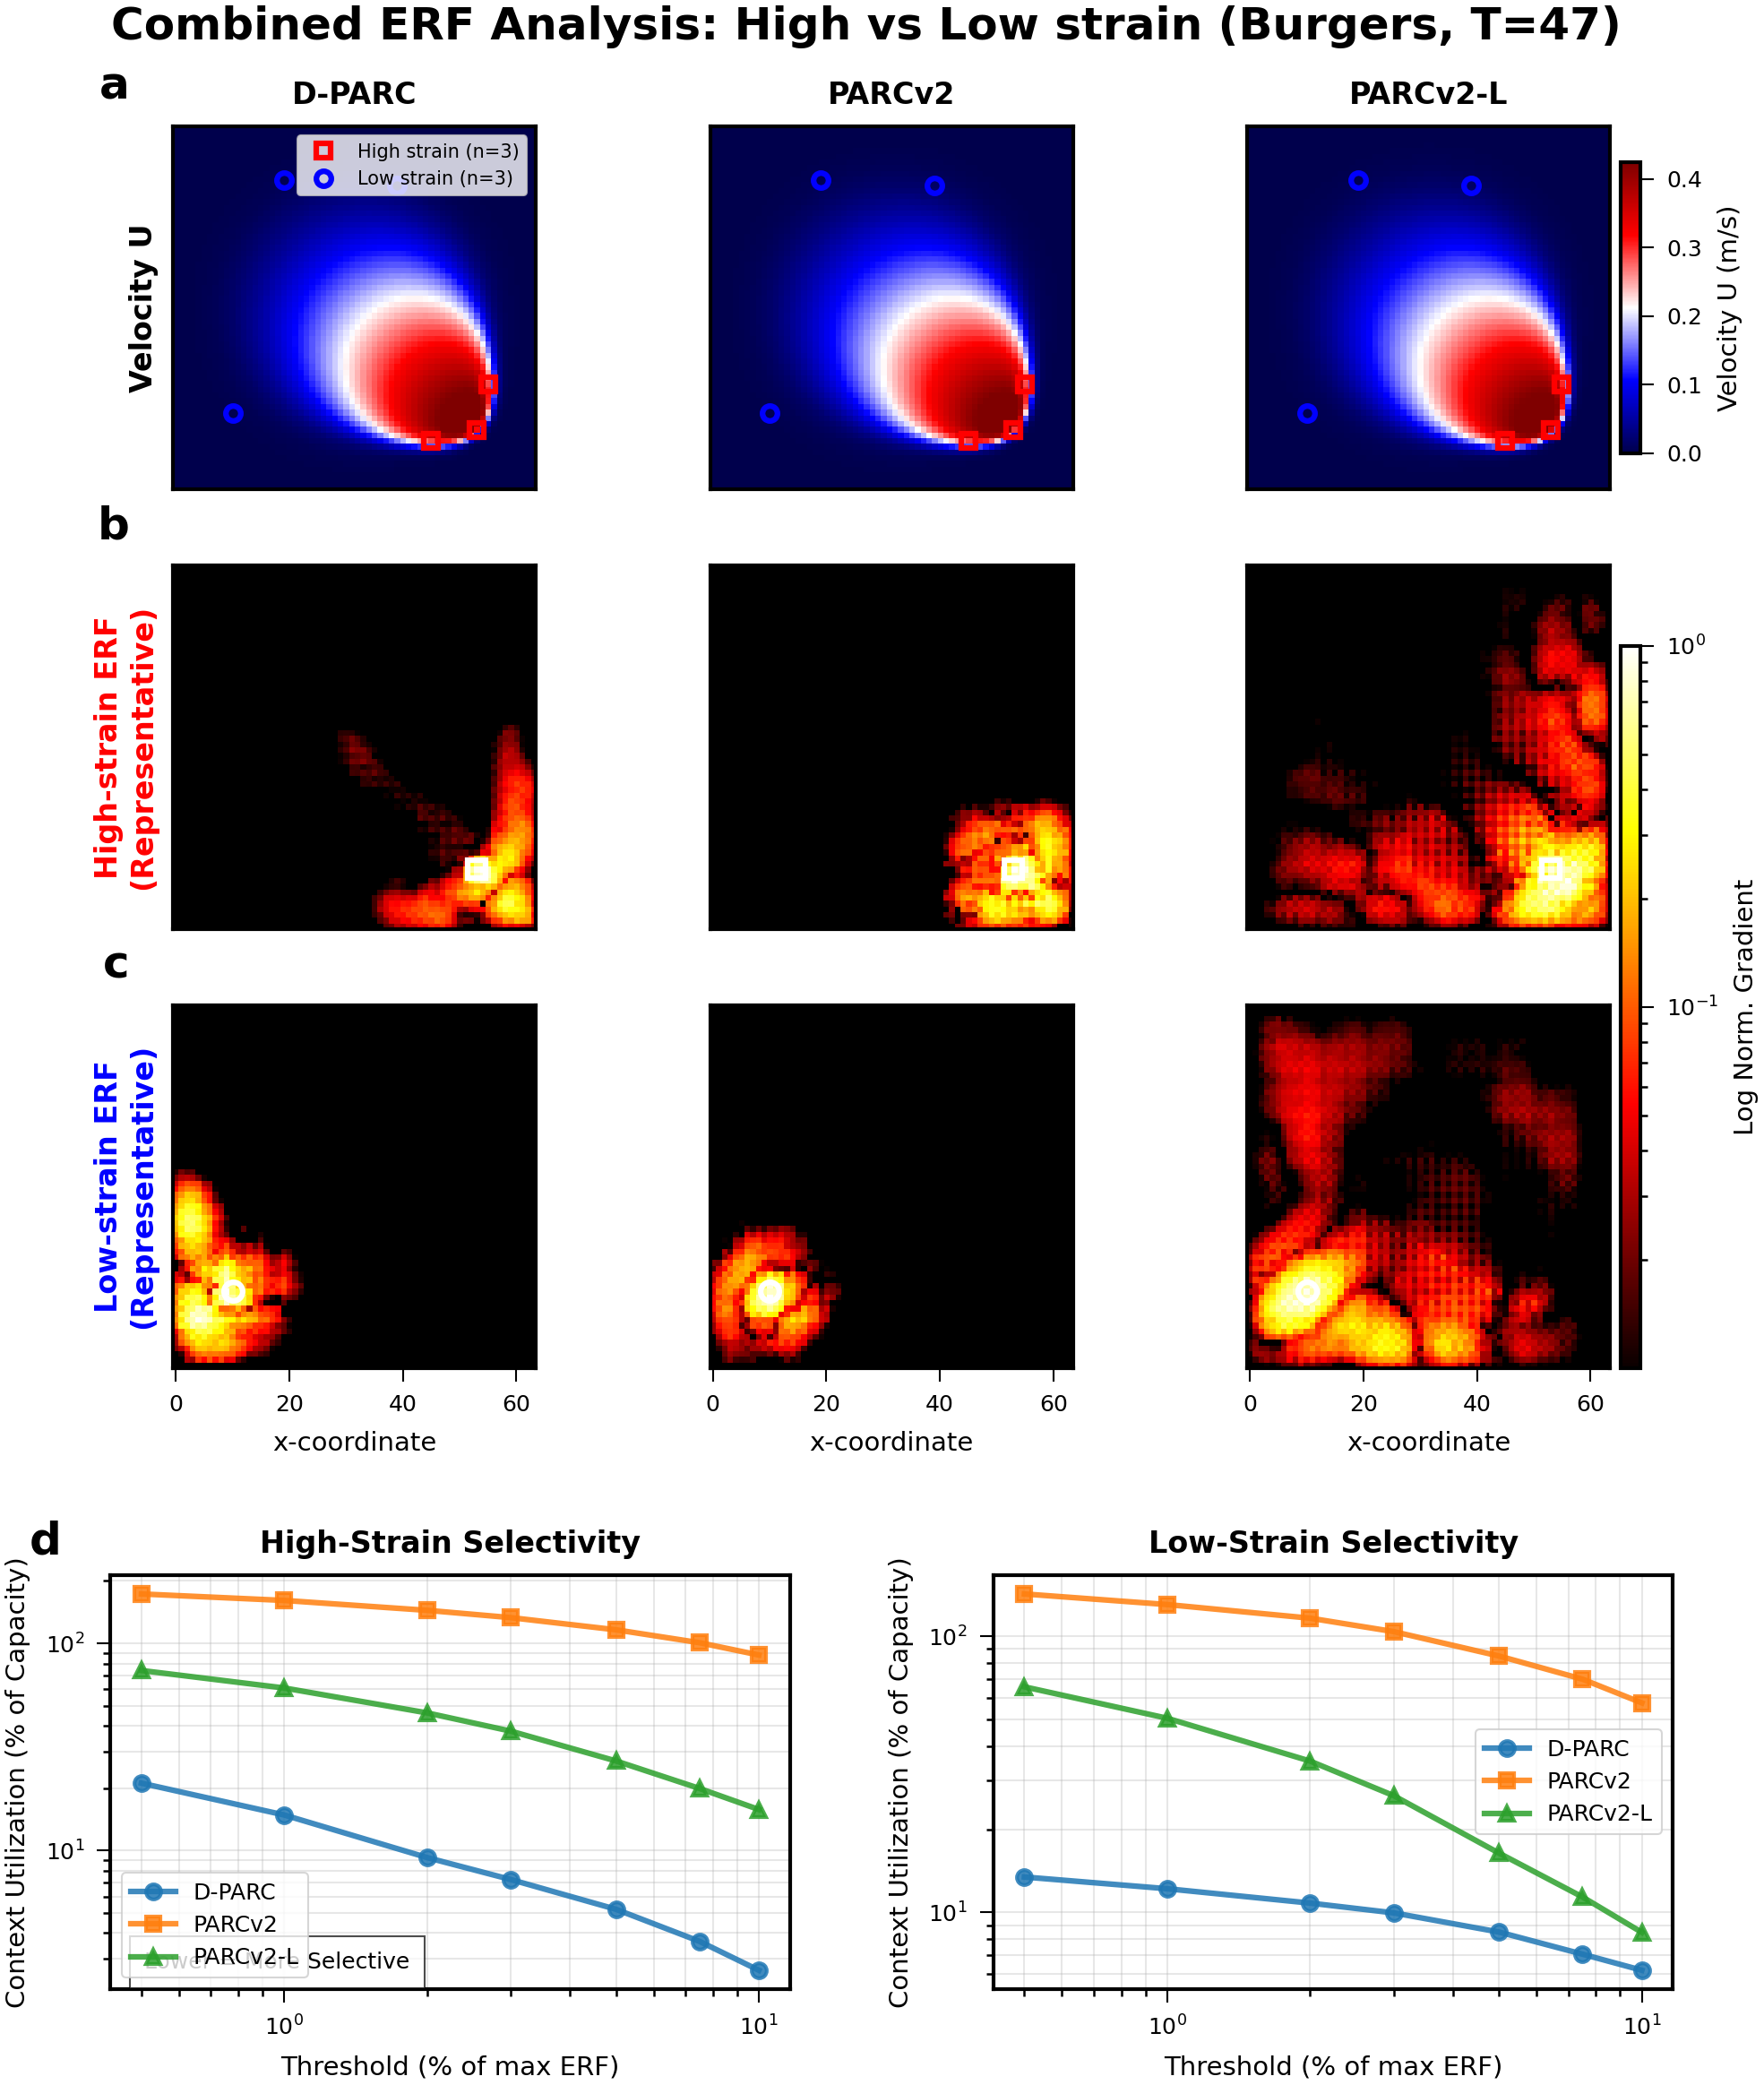


✓ Combined figure generation complete.


In [32]:
################################################################################
# CELL: Combined Publication Figure - High vs Low Strain (Burgers)
# UPDATED: MATCHING NAVIER-STOKES FORMAT (CONTEXT UTILIZATION %)
# UPDATED: Renamed PARC-v2 -> PARCv2 and Large -> PARCv2-L
################################################################################
"""
Generates a single, combined publication figure from the multi-point
analysis, with refined colorbar placement and reduced whitespace.

Updates:
- Renamed models: PARC-v2 -> PARCv2, Large -> PARCv2-L
- Panel 'd' now plots CONTEXT UTILIZATION: (Area / Capacity) * 100
- PARCv2 Capacity = 6,084 pixels (TRF)
- D-PARC/PARCv2-L Capacity = HxW (Global)
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import numpy as np
import gc
from pathlib import Path

print("\n" + "="*80)
print("GENERATING COMBINED FIGURE - BURGERS (CONTEXT UTILIZATION)")
print("RENAMED: PARCv2 & PARCv2-L")
print("="*80)

# Define analysis points
# For Burgers: High-strain regions have strong velocity gradients
# You should adjust these points based on your data!
HIGH_STRAIN_POINTS = [
    (53, 53),    # Point 1 - High gradient (shock)
    (49, 53),    # Point 2 - High gradient
    (55, 45),    # Point 3 - High gradient
]

LOW_STRAIN_POINTS = [
    (50, 10),    # Point 1 - Low gradient (smooth)
    (9, 9),     # Point 2 - Low gradient
    (7, 51),    # Point 3 - Low gradient
]

# Thresholds to test
TEST_THRESHOLDS = [0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.10]

# =============================================================================
# Sub-plotter: Panels (a, b, c) - Velocity + ERF Grids
# =============================================================================

def plot_panel_a_b_c_velocity_erf(
    fig, gs_panel,
    state_d_np, state_s_np, state_l_np,
    erf_high_d_masked, erf_high_s_masked, erf_high_l_masked, point_high,
    erf_low_d_masked, erf_low_s_masked, erf_low_l_masked, point_low,
    all_high_points, all_low_points,
    vmin, vmax, vmin_shared
):
    """
    Draws the 3x3 grid and labels them as panels a, b, and c.
    """
    gs_sub = gridspec.GridSpecFromSubplotSpec(3, 3, subplot_spec=gs_panel,
                                              hspace=0.21, wspace=0.1)

    high_marker_props = {'marker': 's', 'markersize': 4, 'markerfacecolor': 'none',
                         'markeredgecolor': 'red', 'markeredgewidth': 1.5, 'linestyle': 'none'}
    low_marker_props = {'marker': 'o', 'markersize': 4, 'markerfacecolor': 'none',
                        'markeredgecolor': 'blue', 'markeredgewidth': 1.5, 'linestyle': 'none'}

    vel_axes = []
    erf_axes = []

    # --- Panel (a) References ---
    ax_a_ref, ax_b_ref, ax_c_ref = None, None, None

    # --- Row 0: Panel (a) - Velocity Input ---
    # UPDATED LABELS
    for col, (vel_data, title) in enumerate([
        (state_d_np, 'D-PARC'),
        (state_s_np, 'PARCv2'),     # Renamed
        (state_l_np, 'PARCv2-L')    # Renamed
    ]):
        ax = fig.add_subplot(gs_sub[0, col])
        if col == 0:
            ax_a_ref = ax # Anchor panel (a) label
        im = ax.imshow(vel_data, cmap='seismic', vmin=vmin, vmax=vmax)
        vel_axes.append(ax)

        for pt in all_high_points:
            ax.plot(pt[1], pt[0], **high_marker_props)
        for pt in all_low_points:
            ax.plot(pt[1], pt[0], **low_marker_props)

        ax.set_title(title, fontweight='bold', fontsize=8)

        if col == 0:
            ax.set_ylabel('Velocity U', fontweight='bold', fontsize=8)
            legend_elements = [
                Line2D([0], [0], **high_marker_props, label=f'High strain (n={len(all_high_points)})'),
                Line2D([0], [0], **low_marker_props, label=f'Low strain (n={len(all_low_points)})')
            ]
            ax.legend(handles=legend_elements, fontsize=5, loc='upper right')

        ax.set_xticks([])
        ax.set_yticks([])

    # Add single colorbar for Velocity row
    pos_last_ax = vel_axes[-1].get_position()
    pos_first_ax = vel_axes[0].get_position()
    cbar_ax_vel = fig.add_axes([
        pos_last_ax.x1 + 0.005,
        pos_first_ax.y0 + pos_first_ax.height * 0.1,
        0.01,
        pos_first_ax.height * 0.8
    ])
    fig.colorbar(im, cax=cbar_ax_vel, label='Velocity U (m/s)')
    cbar_ax_vel.yaxis.label.set_fontsize(7)
    cbar_ax_vel.tick_params(labelsize=6)

    # --- Row 1: Panel (b) - High-strain ERF ---
    # UPDATED LABELS
    for col, (erf_data, title) in enumerate([
        (erf_high_d_masked, 'D-PARC'),
        (erf_high_s_masked, 'PARCv2'),    # Renamed
        (erf_high_l_masked, 'PARCv2-L')   # Renamed
    ]):
        ax = fig.add_subplot(gs_sub[1, col])
        if col == 0:
            ax_b_ref = ax # Anchor panel (b) label
        ax.set_facecolor('black')
        im_erf = ax.imshow(erf_data, cmap='hot',
                           norm=LogNorm(vmin=vmin_shared, vmax=1.0))
        erf_axes.append(ax)
        ax.plot(point_high[1], point_high[0], 's', markersize=5,
                markerfacecolor='none', markeredgecolor='white', markeredgewidth=1.5)
        if col == 0:
            ax.set_ylabel('High-strain ERF\n(Representative)', fontweight='bold', color='red', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    # --- Row 2: Panel (c) - Low-strain ERF ---
    # UPDATED LABELS
    for col, (erf_data, title) in enumerate([
        (erf_low_d_masked, 'D-PARC'),
        (erf_low_s_masked, 'PARCv2'),     # Renamed
        (erf_low_l_masked, 'PARCv2-L')    # Renamed
    ]):
        ax = fig.add_subplot(gs_sub[2, col])
        if col == 0:
            ax_c_ref = ax # Anchor panel (c) label
        ax.set_facecolor('black')
        im_erf = ax.imshow(erf_data, cmap='hot',
                           norm=LogNorm(vmin=vmin_shared, vmax=1.0))
        erf_axes.append(ax)
        ax.plot(point_low[1], point_low[0], 'o', markersize=5,
                markerfacecolor='none', markeredgecolor='white', markeredgewidth=1.5)
        ax.set_xlabel('x-coordinate', fontsize=7)
        if col == 0:
            ax.set_ylabel('Low-strain ERF\n(Representative)', fontweight='bold', color='blue', fontsize=8)

        ax.tick_params(axis='x', labelsize=6)
        ax.set_yticks([])

    # Add single colorbar for ERF rows (b and c)
    pos_last_ax_low = erf_axes[-1].get_position()
    pos_first_ax_high = erf_axes[0].get_position()
    cbar_ax_erf = fig.add_axes([
        pos_last_ax_low.x1 + 0.005,
        pos_last_ax_low.y0,
        0.01,
        (pos_first_ax_high.y1 - pos_last_ax_low.y0) * 0.9
    ])
    fig.colorbar(im_erf, cax=cbar_ax_erf, label='Log Norm. Gradient')
    cbar_ax_erf.yaxis.label.set_fontsize(7)
    cbar_ax_erf.tick_params(labelsize=6)

    # --- Add Panel Labels (a, b, c) ---
    label_props = {'fontsize': 12, 'fontweight': 'bold', 'va': 'bottom', 'ha': 'right'}

    ax_a_ref.text(-0.12, 1.05, 'a', transform=ax_a_ref.transAxes, **label_props)
    ax_b_ref.text(-0.12, 1.05, 'b', transform=ax_b_ref.transAxes, **label_props)
    ax_c_ref.text(-0.12, 1.05, 'c', transform=ax_c_ref.transAxes, **label_props)

# =============================================================================
# Sub-plotter: Panel (d) - Context Utilization (LOG-LOG ONLY)
# =============================================================================

def plot_panel_d_utilization(fig, gs_panel, high_areas, low_areas, thresholds,
                             parcv2_denom, dparc_denom):
    """
    Panel (d): Context Utilization for Burgers
    Utilization = (Area / Capacity) * 100
    """
    gs_sub = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=gs_panel, wspace=0.3
    )

    thresh_percent = np.array(thresholds) * 100
    line_props = {'linewidth': 1.5, 'markersize': 4, 'alpha': 0.85}

    # Capacity mapping
    denoms = {
        'D-PARC': dparc_denom,
        'PARCv2': parcv2_denom,
        'PARCv2-L': dparc_denom
    }

    def utilization(model, areas):
        return [(a / denoms[model]) * 100 for a in areas]

    # ================= HIGH STRAIN =================
    ax = fig.add_subplot(gs_sub[0, 0])
    ax.text(-0.12, 1.05, 'd', transform=ax.transAxes,
            fontsize=12, fontweight='bold')

    for model, style in [('D-PARC', 'o-'), ('PARCv2', 's-'), ('PARCv2-L', '^-')]:
        ax.loglog(
            thresh_percent,
            utilization(model, high_areas[model]),
            style,
            label=model,
            **line_props
        )

    ax.set_title('High-Strain Selectivity', fontsize=8, fontweight='bold')
    ax.set_xlabel('Threshold (% of max ERF)', fontsize=7)
    ax.set_ylabel('Context Utilization (% of Capacity)', fontsize=7)
    ax.legend(fontsize=6)
    ax.grid(True, which='both', alpha=0.3)
    ax.tick_params(labelsize=6)

    ax.text(0.05, 0.05, 'Lower = More Selective',
            transform=ax.transAxes, fontsize=6,
            bbox=dict(facecolor='white', alpha=0.7))

    # ================= LOW STRAIN =================
    ax = fig.add_subplot(gs_sub[0, 1])

    for model, style in [('D-PARC', 'o-'), ('PARCv2', 's-'), ('PARCv2-L', '^-')]:
        ax.loglog(
            thresh_percent,
            utilization(model, low_areas[model]),
            style,
            label=model,
            **line_props
        )

    ax.set_title('Low-Strain Selectivity', fontsize=8, fontweight='bold')
    ax.set_xlabel('Threshold (% of max ERF)', fontsize=7)
    ax.set_ylabel('Context Utilization (% of Capacity)', fontsize=7)
    ax.legend(fontsize=6)
    ax.grid(True, which='both', alpha=0.3)
    ax.tick_params(labelsize=6)


# =============================================================================
# Main Orchestrator Function
# =============================================================================

def plot_combined_high_low_strain_figure(
    all_results,
    state_d, state_s, state_l,
    norm_params,
    all_high_points, all_low_points,
    thresholds,
    timestep, vmin, vmax,
    output_dir
):
    """
    Main function to generate the combined multi-panel figure for Burgers.
    """
    print("\n[Info] Preparing data for combined figure...")
    set_plot_style()

    # --- 0. Define Denominators ---
    # Global Domain (HxW) from input state shape
    H, W = state_d.shape[-2], state_d.shape[-1]
    GLOBAL_AREA = H * W
    TRF_AREA = 324 # Fixed PARCv2 TRF
    
    print(f"  -> Using Global Capacity: {GLOBAL_AREA} px")
    print(f"  -> Using PARCv2 TRF Capacity: {TRF_AREA} px")
    
    # UPDATED KEYS
    denoms = {
        'D-PARC': GLOBAL_AREA,
        'PARCv2-L': GLOBAL_AREA,
        'PARCv2': min(TRF_AREA, GLOBAL_AREA)
    }

    # --- 1. Data Prep for Panel (a) - Velocity U ---
    channel_idx = 1  # Velocity U for Burgers (0=Reynolds, 1=U, 2=V)
    state_d_np = denormalize_channel(state_d[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_s_np = denormalize_channel(state_s[0, channel_idx].cpu().numpy(), channel_idx, norm_params)
    state_l_np = denormalize_channel(state_l[0, channel_idx].cpu().numpy(), channel_idx, norm_params)

    # Auto-scale if needed
    if vmin is None or vmax is None:
        all_data = np.concatenate([state_d_np.flatten(), state_s_np.flatten(), state_l_np.flatten()])
        vmin = np.percentile(all_data, 1)
        vmax = np.percentile(all_data, 99)

    # NOTE: Using OLD KEYS to fetch data
    erf_high_d = all_results['D-PARC']['high_strain']['point_1']['erf_map']
    erf_high_s = all_results['PARC-v2']['high_strain']['point_1']['erf_map']
    erf_high_l = all_results['Large']['high_strain']['point_1']['erf_map']
    point_high = all_high_points[0]

    erf_low_d = all_results['D-PARC']['low_strain']['point_1']['erf_map']
    erf_low_s = all_results['PARC-v2']['low_strain']['point_1']['erf_map']
    erf_low_l = all_results['Large']['low_strain']['point_1']['erf_map']
    point_low = all_low_points[0]

    def process_erf(erf_map):
        erf_agg = np.sum(erf_map, axis=0)
        erf_norm = erf_agg / (erf_agg.max() + 1e-10)
        threshold = 0.01
        erf_masked = np.where(erf_norm > threshold, erf_norm, np.nan)
        return erf_masked

    erf_high_d_masked = process_erf(erf_high_d)
    erf_high_s_masked = process_erf(erf_high_s)
    erf_high_l_masked = process_erf(erf_high_l)
    erf_low_d_masked = process_erf(erf_low_d)
    erf_low_s_masked = process_erf(erf_low_s)
    erf_low_l_masked = process_erf(erf_low_l)

    def safe_nanmin(arr, default=1e-3):
        valid = arr[~np.isnan(arr)]
        return valid.min() if len(valid) > 0 else default

    vmin_shared = min([
        safe_nanmin(erf_high_d_masked), safe_nanmin(erf_high_s_masked), safe_nanmin(erf_high_l_masked),
        safe_nanmin(erf_low_d_masked), safe_nanmin(erf_low_s_masked), safe_nanmin(erf_low_l_masked)
    ])

    # --- 2. Data Prep for Panel (d) ---
    # Fetch with OLD keys -> Store with NEW keys
    high_areas = {
        'D-PARC': [all_results['D-PARC']['high_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARCv2': [all_results['PARC-v2']['high_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARCv2-L': [all_results['Large']['high_strain']['average'][t]['area_mean'] for t in thresholds]
    }
    low_areas = {
        'D-PARC': [all_results['D-PARC']['low_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARCv2': [all_results['PARC-v2']['low_strain']['average'][t]['area_mean'] for t in thresholds],
        'PARCv2-L': [all_results['Large']['low_strain']['average'][t]['area_mean'] for t in thresholds]
    }

    # --- 3. Create Figure and Layout ---
    print("[Info] Building combined figure...")
    fig = plt.figure(figsize=(7.5, 9))

    # Layout: Top panel gets 3x more space, increased hspace for labels
    main_gs = gridspec.GridSpec(2, 1, figure=fig,
                                height_ratios=[3, 1], hspace=0.25)

    gs_abc = main_gs[0] # Gridspec for panels a, b, c
    gs_d = main_gs[1]   # Gridspec for panel d

    # --- 4. Call Sub-plotters ---
    plot_panel_a_b_c_velocity_erf(
        fig, gs_abc,
        state_d_np, state_s_np, state_l_np,
        erf_high_d_masked, erf_high_s_masked, erf_high_l_masked, point_high,
        erf_low_d_masked, erf_low_s_masked, erf_low_l_masked, point_low,
        all_high_points, all_low_points,
        vmin, vmax, vmin_shared
    )

    plot_panel_d_utilization(
    fig, gs_d,
    high_areas, low_areas, TEST_THRESHOLDS,
    parcv2_denom=denoms['PARCv2'],
    dparc_denom=denoms['D-PARC']
)


    # --- 5. Finalize and Save ---
    fig.suptitle(f'Combined ERF Analysis: High vs Low strain (Burgers, T={timestep})',
                 fontsize=12, fontweight='bold', y=0.93)

    output_path = output_dir / f'COMBINED_high_low_strain_T{timestep}_burgers_UTILIZATION.png'
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"\n✓ Saved combined figure to: {output_path}")

    output_path_pdf = output_path.with_suffix('.pdf')
    plt.savefig(output_path_pdf, bbox_inches='tight')
    print(f"✓ Saved combined figure to: {output_path_pdf}")

    plt.show()
    plt.close(fig)
    gc.collect()

# =============================================================================
# Run the Combined Plotting
# =============================================================================

try:
    plot_combined_high_low_strain_figure(
        all_results,
        state_at_t_deform, state_at_t_standard, state_at_t_large,
        norm_params,
        HIGH_strain_POINTS, # Kept original variable name
        LOW_strain_POINTS,  # Kept original variable name
        TEST_THRESHOLDS,
        ANALYZE_TIMESTEP,
        VMIN_VIZ,
        VMAX_VIZ,
        OUTPUT_DIR
    )
except NameError as e:
    print(f"\n[ERROR] Required data not found: {e}")
    print("Please ensure you have successfully run the 'Multi-Point ERF Analysis' cell")
    print("to generate the required variables before running this cell.")
except Exception as e:
    print(f"\n[ERROR] An unexpected error occurred: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)
print("✓ Combined figure generation complete.")
print("="*80)